# What does a forecast buy a home battery, and on which tariff?

One continuous MILP, driven by a Prophet forecast, over a 10 kWh / 1.5 kW battery on
30 Ausgrid households and a full simulated year — measured against the controllers a
household could actually install, on two price signals that reward completely different
behaviour.

### The households

30 sites, one per cluster: the centroid-nearest member of each of 30 k-means clusters over
all 300 Ausgrid households. They span the consumption shapes present in the population
rather than being a convenience sample, and `hems_study.study_units()` derives them from
the clustering rather than restating a list, so the rule is executable.

### The tariff axis

| | |
|---|---|
| **AU** | Ausgrid EA025 time-of-use on `Australia/Sydney`, working-day aware, spot-linked. Energy and a standing charge; **no capacity charge**. |
| **SI** | GEN-I Dinamični under `si_samooskrba`. Energy, a standing charge, **and an excess-power charge** measured per network block against a *dogovorjena obračunska moč* that is re-agreed each month from the peaks the controller itself realised the month before. |

The contract is therefore endogenous on SI: a controller that shaves its way onto a lower
agreed power is then held to it, and one that charges at night pays for the peak it made.
`Environment.converge_agreed_power` iterates each run to that fixed point.

### The controller axis

Every controller decides one interval at a time from what it can know, and all of them are
executed on the same battery and priced by the same evaluator — they differ *only* in how a
setpoint is chosen.

| | |
|---|---|
| `no_battery` | the reference, run as an idle policy so it carries every column the others do |
| `self_consumption` | what a residential inverter ships with: soak the surplus, cover the deficit, never trade |
| `fixed_schedule`, `delayed_pv_charge` | a clock, and feed-in damping |
| `price_threshold`, `price_rank_daily`, `tariff_arbitrage` | trade on the published day-ahead price |
| `peak_shaving`, `self_consumption_peak_shaving` | watch the meter (SI only — there is no capacity charge on AU for them to earn from) |
| `price_oracle` | `price_threshold` reading forward instead of backward. **Not deployable**; it bounds what foresight is worth to a threshold rule |
| `prophet` | the MILP on a Prophet forecast — the study's subject |
| `oracle` | the same MILP on realised data: perfect foresight *within the control horizon* |
| `milp_full` | one MILP over the **whole scored year**, perfect foresight throughout. Not deployable either; it is the denominator every `gain_share_pct` divides by, and no controller above gets underneath it on the total |

**Which column the ranking is read on matters, and it is not the energy bill.** `milp_full`
bounds `saving_total` — bill, standing charge *and* wear — and nothing else. On `saving_pct`,
the share of the energy bill alone, three AU price rules score *above* it, at up to 106.6 %
of a gain that is supposed to be a ceiling: they buy their saving out of pack life (225 EFC
against the optimum's 127) and a measure that cannot see wear books the proceeds. Every
comparison figure below is drawn on `saving_total_pct`, the share the label is true of.

### The objective axis

The MILP controllers pay a wear shadow price for the cycles they spend —
`cycle_cost_eur_per_efc`, the pack price over its rated cycle life, 0.417 per EFC on a
10 kWh pack at 250 EUR/kWh and 6000 EFC. The `*_nowear` arms are the same arms with that
term removed from the objective, and they are the study's ablation: everything else —
battery, tariff, forecast, evaluator, horizon — is the twin's, so anything that differs
between the pair is the wear term and nothing else. The rules never consulted a wear price
in any arm, so their rows are expected to be identical across the pair, which is the control.

**The pack still wears.** Removing the term changes what the MILP *decides*, not what the
cells *cost*. A separate accounting rate stays at the pack price on these arms, so
`wear_eur`, `saving_total` and every NPV bill them for their cycles like everyone else.
Figures mark them with a `*`.

### The forecast axis

Only the two MPC rows above are forecast-driven, and what they are fed is the study's third
axis. Every method forecasts both channels a day ahead, on the same anchors, scored by the
same `forecast_error_metrics`; the `PV:` and `+ perfect PV` arms vary the two channels
separately, because a single "with forecast" number averages them and hides which one the
money is in.

| | |
|---|---|
| `persistence`, `weekly`, `daytype` | copy yesterday, last week, the last like-day. `persistence` is the baseline `skill` is measured against |
| `mean3/7`, `median7/14` | climatology: the mean or median of the last *n* days at the same clock position |
| `prophet`, `prophet_tuned` | Prophet at the module defaults, and at the settings `tune_prophet` picked. Fits on the training block and refits every 30 days; **reads no recent actual at prediction time** |
| `hbd`, `hbd_baseline`, `hbd_median14` | the ported competing method — see below |
| `pvtruth`, `truth` | perfect foresight on one channel or both. Not deployable; they bound what a perfect forecast is worth |

`hbd` is a port of the forecaster from **Perez-Pineiro, Skogestad & Boyd, "Home battery
dispatch under a tiered peak power tariff"** (*Optimization and Engineering*, 2026),
[cvxgrp/home-battery-dispatch](https://github.com/cvxgrp/home-battery-dispatch), as
`Yoann/hbd_forecast.py` plus the `HbdForecaster` adapter in `hems_study.py`. It is two
stages: a seasonal Fourier baseline fit by quantile regression, plus a residual AR matrix
mapping the last day of residuals onto the next day's. It is in this study because it is the
only method in the roster that *both* fits a model and conditions on recent actuals — the
term Prophet and the naive kinds each half have. `hbd_baseline` is the paper's own ablation
(stage 1 alone) and prices the AR stage; `hbd_median14` is **not** the paper's method — it is
the paper's stage 2 on this study's own best stage 1. Two departures from the source are
deliberate and are in the caveats below.

### What makes the comparison fair

One battery (`align_envelope`), one environment, one settlement. The MILP used to solve its
own copy of the battery while the rules read the environment's, which differ by `eff²` — a
5.3 % larger charge rating and a 5.0 % smaller discharge rating — and the two were priced by
different functions. Both are now shared, and `Cost_EUR_Closed` values any energy left in the
pack at the end at the mean delivered import rate, so a rule that runs the battery flat in
December cannot book the difference as a saving.

In [1]:
### Imports
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import hems_study as hs
hs = importlib.reload(hs)

print(f"hems_study loaded: {len(hs.STUDY_ARMS)} arms, "
      f"{len(hs.rule_roster('SI')) + 1} controllers on SI, "
      f"{len(hs.rule_roster('AU')) + 1} on AU.")

/Users/summerscholl/Library/Python/3.14/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


hems_study loaded: 35 arms, 10 controllers on SI, 8 on AU.


## 1. Configuration

Everything the study computes lives in `hems_study.py`; this notebook configures it, reads
what it wrote and draws the figures. `RUN_SWEEP = True` recomputes the lot — hours — and by
default the notebook loads the CSVs the sweep already produced. Work is checkpointed per
(arm, household), and a checkpoint carries the configuration it was produced under, so a run
under superseded rules is dropped rather than resumed into.

In [2]:
import inspect

UNITS = hs.study_units()               # household -> the cluster it represents
ARMS = list(hs.ARM_ORDER)
RESULTS_DIR = hs.RESULTS_DIR
RUN_SWEEP = True                      # True -> recompute everything, resumable
N_SIM = 365
# Households in parallel, one process each. The sweep is len(ARMS) x len(UNITS)
# independent checkpointed runs -- printed below rather than written here, which
# is how the old hardcoded count came to be wrong. The household is the unit
# because every cache -- the forecast table, the fitted forecaster parameters
# and the forecast-blind oracle -- is keyed per household, so one worker owning
# a household means full cache reuse and no races. N_JOBS = 1 is the old serial
# behaviour.
N_JOBS = 10

# The battery, the horizons and the training window, READ FROM THE PIPELINE
# rather than typed. These were four lines of prose describing defaults that
# live in `run_pipeline_for_file` -- exactly the second source of truth the run
# count above was, and the count is the one that came out wrong. Deriving them
# means a changed default cannot be described here as the old one.
_D = {k: v.default for k, v in
      inspect.signature(hs.run_pipeline_for_file).parameters.items()}
_usable = _D["battery_cap"] * (_D["soc_max_pct"] - _D["soc_min_pct"])
_hz = sorted({a.get("control_horizon", _D["H"]) for a in hs.STUDY_ARMS},
             reverse=True)

print(f"households    : {len(UNITS)}, one per k-means cluster over all 300 Ausgrid sites")
print(f"battery       : {_D['battery_cap']:.0f} kWh nameplate, {_usable:.1f} kWh "
      f"usable (SOC {_D['soc_min_pct']:.0%}-{_D['soc_max_pct']:.0%}), "
      f"{_D['p_max']} kW AC, eff {_D['eff']}")
print(f"horizon       : "
      + ", ".join(f"{hs.horizon_label(h, _D['delta_t'])} ({h} steps)" for h in _hz)
      + f" at {_D['delta_t'] * 60:.0f}-minute resolution")
print(f"simulation    : {N_SIM} days after {_D['n_train']} days of training data")
print(f"solver        : {hs.SOLVER_NAME}"
      f"{' (in-process; no subprocess per solve)' if hs.SOLVER_NAME == 'HiGHS' else ''}")
print(f"parallelism   : {N_JOBS} worker(s) over {len(UNITS)} households")
print(f"runs          : {len(ARMS)} arms x {len(UNITS)} households "
      f"= {len(ARMS) * len(UNITS)} checkpointed runs")

print(f"\narms          : {len(ARMS)}")
for arm in hs.STUDY_ARMS:
    spec = {k: v for k, v in arm.items() if k != "name"}
    # Same overflow as the table in the next section: eleven arm names are
    # longer than 18 characters, so their specs started in a different column.
    print(f"   {arm['name']:{max(len(a) for a in hs.ARM_ORDER)}s}  {spec}")

print(f"\ncontrollers")
for tariff in ("AU", "SI"):
    names = ["no_battery"] + [p.name for p in hs.rule_roster(tariff)] + ["prophet", "oracle"]
    print(f"   {tariff}: {', '.join(names)}")

print(f"\nreference arms: {hs.REFERENCE_ARM}")
print("The two peak-shaving rules run on SI only: Ausgrid EA025 as modelled carries no")
print("capacity charge, so on AU they could only spend round-trip losses.")

# THE ABLATION, named where the roster is. `*_nowear` is not another forecaster
# and not another horizon: it is the same arm with `cycle_cost_eur_per_efc = 0`,
# i.e. the wear shadow price taken out of the MILP objective. Everything else --
# battery, tariff, forecast, evaluator, horizon -- is its twin's.
#
# It is the control the study was missing. Every result here is stated under an
# objective that already prices pack life, so "the MILP saves less than a price
# rule on the energy bill" had two possible causes, the horizon or the wear term,
# and nothing separated them.
#
# The pack still wears. `cycle_cost_reporting_eur_per_efc` stays at the pack
# price on these arms, so `wear_eur`, `saving_total` and every NPV bill them for
# the cycles they spend at the same rate as everyone else -- see the note in
# `hs.summarize`, where a solved rate of zero is the one value never read back as
# an accounting rate.
_nw = [a["name"] for a in hs.STUDY_ARMS if a["name"].endswith("_nowear")]
print(f"\nno-degradation arms: {len(_nw)} -- {', '.join(_nw)}")
print("   the same MILP with the wear term removed from its objective; the rules in")
print("   these arms never consulted a wear price and are expected to be identical.")
import Battery_Economics as _be
_rate = _be.cycle_cost_eur_per_efc(_D["battery_cap"])
print(f"   dispatch rate  {_rate:.4f}/EFC where priced, 0.0000 on the no-wear arms")
print(f"   accounting     {_rate:.4f}/EFC on every arm alike "
      f"({_be.CAPEX_EUR_PER_KWH:.0f} EUR/kWh over "
      f"{_be.BATTERY_CYCLE_LIMIT_EFC:.0f} EFC)")

households    : 30, one per k-means cluster over all 300 Ausgrid sites
battery       : 10 kWh nameplate, 7.0 kWh usable (SOC 10%-80%), 1.5 kW AC, eff 0.95
horizon       : 24 h (48 steps), 11 h (22 steps) at 30-minute resolution
simulation    : 365 days after 730 days of training data
solver        : HiGHS (in-process; no subprocess per solve)
parallelism   : 10 worker(s) over 30 households
runs          : 35 arms x 30 households = 1050 checkpointed runs

arms          : 35
   AU_H24                       {'tariff': 'AU', 'control_horizon': 48}
   AU_H11                       {'tariff': 'AU', 'control_horizon': 22}
   SI_H24                       {'tariff': 'SI', 'control_horizon': 48}
   SI_H11                       {'tariff': 'SI', 'control_horizon': 22}
   AU_H24_leaked                {'tariff': 'AU', 'control_horizon': 48, 'leak_current_interval': True}
   AU_H24_persist               {'tariff': 'AU', 'control_horizon': 48, 'forecaster_kind': 'persistence'}
   SI_H24_persist        

## 2. Run or load

One checkpoint per (arm, household). Only households that finished every arm enter the
comparison, so a difference between arms is not a difference in sample.

In [3]:
if RUN_SWEEP:
    # `run_arms` now prints how many of these runs it EXECUTED and how many it
    # read back from checkpoints. Both used to be reported as "930/930 runs
    # succeeded in 1.2 min", which is the cost of reading 930 JSON files and
    # reads as a machine forty times faster than the one section 6 measured.
    _swept = hs.run_arms(
        data_dir=str(Path("..") / "Input data" / "Ausgrid"),
        output_root=str(RESULTS_DIR),
        dataset_ids=hs.dataset_ids(),
        n_sim=N_SIM,
        n_jobs=N_JOBS,
    )

df_all = hs.collect_results(RESULTS_DIR)
if df_all.empty:
    # RuntimeError, not SystemExit: IPython CATCHES SystemExit, prints almost
    # nothing and lets "Run All" carry straight on into the next cell, which
    # then fails on an undefined `long` and buries the real message under a
    # NameError. A notebook needs the traceback that stops the run.
    raise RuntimeError(
        f"No results in {RESULTS_DIR}.\n"
        f"Run  python hems_study.py  (hours, resumable), or set RUN_SWEEP = True above."
    )

# 29, not 20: six arm names are longer than that and `AU_H24_hbd_median14_pvtruth`
# is 27, so the columns to the right of them used to be pushed out of line and
# the table stopped being readable exactly where the newest arms are.
_w = max(len(a) for a in hs.ARM_ORDER) + 2
print(f"{'arm':{_w}s}{'tariff':>8s}{'households':>12s}{'with roster':>13s}")
for arm in sorted(df_all["arm"].unique(), key=hs.ARM_ORDER.index):
    sub = df_all[df_all["arm"] == arm]
    print(f"{arm:{_w}s}{str(sub['tariff'].iloc[0]):>8s}{len(sub):>12d}"
          f"{int(sub['roster_complete'].sum()):>13d}")

# A checkpoint written before the rule roster existed carries cost_prophet and
# cost_oracle but none of the rules. Reading it as though it did is how a partial
# panel gets reported as a whole one, so those rows are held out and said so.
stale = df_all[~df_all["roster_complete"]]
if len(stale):
    print(f"\nHeld out -- no rule-based controllers on these runs, so they predate the "
          f"roster and cannot be compared against it: {len(stale)} run(s) across "
          f"{', '.join(sorted(stale['arm'].unique()))}")
    print("Re-run them with RUN_SWEEP = True to bring them onto the current comparison.")
df_all = df_all[df_all["roster_complete"]].reset_index(drop=True)
if df_all.empty:
    raise RuntimeError(
        "No run carries the rule-based controllers yet, so there is nothing to compare "
        "the MILP against. Run the sweep: python hems_study.py"
    )

# A household enters only if it finished every arm still standing, so a
# difference between arms is not a difference in sample.
arms_present = sorted(df_all["arm"].unique(), key=hs.ARM_ORDER.index)
done = df_all.groupby("dataset")["arm"].nunique()
balanced = set(done[done == len(arms_present)].index)
held = set(df_all["dataset"]) - balanced
if held:
    print(f"\nHeld out to keep the panel balanced (finished some arms, not all): "
          f"{len(held)} -- {', '.join(sorted(held))}")
df_all = df_all[df_all["dataset"].isin(balanced)].reset_index(drop=True)

# A saving PERCENTAGE needs a positive baseline. A net exporter has
# cost_no_battery <= 0, and dividing by it flips the sign, so a site that saves
# money would read as one that loses it.
neg = df_all.loc[df_all["cost_no_battery"] <= 1e-9, "dataset"].unique()
if len(neg):
    print(f"\n! {len(neg)} site(s) have a non-positive no-battery cost; their euro "
          f"columns are valid but every _pct column is NaN: {', '.join(neg)}")

print(f"\nComparing {df_all['dataset'].nunique()} households across "
      f"{len(arms_present)} arms = {len(df_all)} runs.")


######################################################################
### PARALLEL SWEEP: 35 arms x 30 households = 1050 runs, 10 workers
### solver HiGHS; per-household logs under /Users/summerscholl/Documents/ERK-2026/Yoann/results_local/logs/
######################################################################



[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.


[Parallel(n_jobs=10)]: Done   5 tasks      | elapsed:   27.5s


[Parallel(n_jobs=10)]: Done  15 out of  30 | elapsed:   54.1s remaining:   54.1s


[Parallel(n_jobs=10)]: Done  19 out of  30 | elapsed:   54.3s remaining:   31.5s


[Parallel(n_jobs=10)]: Done  23 out of  30 | elapsed:  1.3min remaining:   24.5s


[Parallel(n_jobs=10)]: Done  27 out of  30 | elapsed:  1.3min remaining:    9.0s



All arms: /Users/summerscholl/Documents/ERK-2026/Yoann/results_local/summary_all_arms.csv

=== 1050/1050 runs succeeded in 1.4 min on 10 workers ===
    1050 served from checkpoints
    Nothing was executed: every run was already on disk under this configuration, so the 1.4 min above is the cost of READING 1050 checkpoints, not of producing them.
    What producing them cost is `arm_runtimes`.
arm                            tariff  households  with roster
AU_H24                             AU          30           30
AU_H11                             AU          30           30
SI_H24                             SI          30           30
SI_H11                             SI          30           30
AU_H24_leaked                      AU          30           30
AU_H24_persist                     AU          30           30
SI_H24_persist                     SI          30           30
AU_H24_pvnaive                     AU          30           30
SI_H24_pvnaive                     

[Parallel(n_jobs=10)]: Done  30 out of  30 | elapsed:  1.4min finished


## 3. The comparison table

`saving` is against the same household with no battery, in the arm's own currency (AUD on
AU, EUR on SI) — read percentages *down* a tariff, never across one.

`Gain_share_pct` is the share of the **whole-period optimum's** saving a controller
captured — `milp_full`, one MILP over the entire scored year with perfect foresight
throughout — measured on the quantity that solve actually minimises: bill + standing charge
+ wear. `full_period_bound_check` verifies per run that nothing beats it, and across all 930
household-arms of this sweep nothing does.

Measured on the energy bill alone (`Gain_gross_pct`) the ceiling is *not* a ceiling, and the
difference is instructive rather than cosmetic. Of the 9 270 (household, arm, controller)
rows that are neither the reference nor the optimum, **1157 clear it**, for two different
reasons, and both are the measure failing rather than a
controller winning:

* **Wear is in the optimum's objective and not in the gross measure.** `milp_full` minimises
  bill + standing charge + wear, so a rule that buys a cheaper bill with more cycles beats it
  on bill alone. This is most of the excess: `price_rank_daily` (336 household-arms),
  `price_oracle` (320), `price_threshold` (320) and `oracle` (106) — on AU the price rules
  cycle 225 times a year against the optimum's 127.
* **On SI the contract is endogenous.** `self_consumption_peak_shaving` clears it on 75,
  because the *dogovorjena moč* re-agrees from the peaks the controller itself made, so a
  peak shaver trades a larger energy bill for a smaller contract — which a measure that
  drops the standing charge cannot see.

On the total, which is what the optimum actually minimises, nothing clears it anywhere.

It used to divide by `oracle`, which is perfect foresight only *within the control horizon*
(24 h or 11 h) — a horizon-limited heuristic being called "theoretical". That reading is
kept as `gain_share_pct_vs_mpc_oracle`, because "how much of what an MPC with a perfect
forecast got" is still a real question; it is just not the one the word promised.

Costs are compared on the **total**: bill + standing charge + wear. Every MILP controller
now carries the wear price in its objective, so that total is what they are actually
minimising — and on SI the standing charge moves with the contract the controller's own
peaks agree to, so leaving it out would credit a peak shaver with nothing.

`NPV` and `IRR_pct` are the same run read over the **pack's life** instead of over the
scored year, and they change what the rest of the table means. One solved year of
`saving_total` — bill plus, on SI, the standing charge, net of wear — repeated over a 12-year
calendar life at 5 % real, against the pack priced in the arm's own currency: 3500 EUR on SI,
5691 AUD on AU (250 EUR/kWh plus a 1000 EUR install, converted at the 0.615 the AU tariff
itself uses). The cycle limit is deliberately not applied on top — wear is already subtracted
as cash — and it would not bind anyway: the hardest-cycling controller books ~225 EFC/a
against a 6000 EFC rating, which is 27 years of cycle life under a 12-year calendar band.

Every controller on both tariffs comes out **negative on both**, and that is the result rather
than a bug: at these quotes the ranking is over how far short the pack falls, not over which
one to buy. `IRR_pct` is signed and reports that shortfall as a rate. It is `NaN` — printed
`n/a` — where the saving does not cover the O&M charge, because no discount rate solves
`savings · PVF(r) = capex` when the annuity is non-positive; that is "never, at any rate",
which is a different statement from a large negative one. `IRR_n` says how many of the 30
households have a defined one, so a median IRR and a median NPV cannot silently be read over
different samples.

`NPV` and `IRR_pct` here are the **pack + install** reading, 3500 EUR / 5691 AUD. The pack
on its own — 2500 EUR / 4065 AUD, no hybrid inverter and no fitting — is `npv_pack_only` and
`irr_pct_pack_only` in `long`, and the lifetime figure below plots the two side by side. The
1000 EUR fee is worth 1133 EUR of NPV on SI and 8.1 points of IRR on the optimum, and it is
what puts several SI controllers into "no IRR exists" rather than merely "negative".

**Units.** `Cur` names the currency every money column in that row is in. Money columns are
per household-year, except `NPV`, which is over the whole 12-year life.


In [4]:
long = hs.summarize(df_all)

# One row per (arm, controller): the median household, and the spread across them.
summary = (long.groupby(["arm", "controller"])
           .agg(Households=("cost", "size"),
                Cost=("cost", "median"),
                Saving=("saving", "median"),
                Saving_pct=("saving_pct", "median"),
                # Net of wear, and on SI net of the contract the controller
                # walked itself onto: the quantity `milp_full` minimises, and so
                # the only one its 100 % is a real ceiling on. `Gain_gross_pct`
                # is the old energy-bill reading, kept because a controller that
                # scores well there and badly here is buying its bill out of
                # pack life, which is worth being able to see.
                Saving_net=("saving_net_of_wear", "median"),
                Cost_total=("cost_total", "median"),
                Gain_share_pct=("gain_share_net_pct", "median"),
                Gain_gross_pct=("gain_share_pct", "median"),
                Worst_pct=("saving_pct", "min"),
                Best_pct=("saving_pct", "max"),
                EFC=("efc", "median"),
                # Over the PACK'S LIFE rather than over the scored year, which
                # is the only horizon on which "should a household buy this"
                # has an answer. `NPV` is one solved year of `saving_total`
                # -- bill + standing charge, net of wear -- repeated over a
                # 12 y calendar life at 5 % real, against the pack priced in
                # the arm's own currency. `IRR_pct` is the rate that drives
                # that to zero, and it is signed: every controller here earns a
                # negative one, which is the result, not a bug.
                NPV=("npv", "median"),
                IRR_pct=("irr_pct", "median"),
                # HOW MANY households the IRR median is over. It is NaN where
                # the saving does not cover the O&M charge -- no discount rate
                # solves that, so there is no root to report -- and without this
                # column a median IRR and a median NPV would silently be taken
                # over different samples and could disagree.
                IRR_n=("irr_defined", "sum"))
           .reset_index())
order = {c: i for i, c in enumerate(hs.controller_columns(df_all))}
summary = (summary.assign(Cur=summary["arm"].map(hs.currency),
                          _a=summary["arm"].map(hs.ARM_ORDER.index),
                          _c=summary["controller"].map(order))
           .sort_values(["_a", "_c"]).drop(columns=["_a", "_c"])
           .set_index(["arm", "controller"]))
# `Cur` first: it is the unit every money column below is in, and a unit read
# after the number it qualifies has already been misread once.
summary = summary[["Cur"] + [c for c in summary.columns if c != "Cur"]]

print("units -- Cost, Saving, Saving_net, Cost_total, NPV: the arm's own "
      "currency (`Cur`), AUD on AU and EUR on SI, never comparable across a "
      "tariff.\n"
      "        Cost/Saving/Saving_net/Cost_total are per household-YEAR; NPV is "
      "over the whole 12 y life.\n"
      "        Saving_pct, Gain_*_pct, Worst/Best_pct, IRR_pct: per cent. "
      "EFC: equivalent full cycles per year.\n"
      "        IRR_n: households of {n} with a defined IRR.".format(
          n=long["dataset"].nunique()))
summary.round(2)

units -- Cost, Saving, Saving_net, Cost_total, NPV: the arm's own currency (`Cur`), AUD on AU and EUR on SI, never comparable across a tariff.
        Cost/Saving/Saving_net/Cost_total are per household-YEAR; NPV is over the whole 12 y life.
        Saving_pct, Gain_*_pct, Worst/Best_pct, IRR_pct: per cent. EFC: equivalent full cycles per year.
        IRR_n: households of 30 with a defined IRR.


Cur  Households    Cost  Saving  Saving_pct  \
arm           controller                                                       
AU_H24        no_battery         AUD          30  776.31    0.00        0.00   
              self_consumption   AUD          30  654.19  108.67       13.47   
              fixed_schedule     AUD          30  526.56  213.00       26.59   
              delayed_pv_charge  AUD          30  654.18  108.65       13.46   
              price_threshold    AUD          30  489.67  265.99       32.07   
...                              ...         ...     ...     ...         ...   
SI_H11_nowear price_oracle       EUR          30  275.47   35.05        9.76   
              tariff_arbitrage   EUR          30  288.46   20.30        5.99   
              prophet            EUR          30  305.28   -0.44       -0.11   
              oracle             EUR          30  273.15   39.18       10.59   
              milp_full          EUR          30  262.96   49.86       13.21   

                                 Saving_net  Cost_total  Gain_share_pct  \
arm           controller                                                  
AU_H24        no_battery               0.00      776.31            0.00   
              self_consumption        84.43      670.25           47.85   
              fixed_schedule         162.85      577.01           85.20   
              delayed_pv_charge       84.42      670.25           47.82   
              price_threshold        173.21      576.76           87.68   
...                                     ...         ...             ...   
SI_H11_nowear price_oracle             0.01      463.20           11.58   
              tariff_arbitrage       -56.68      496.84          -77.36   
              prophet                -54.98      511.36         -128.39   
              oracle                 -16.54      473.06           -2.85   
              milp_full              -15.93      433.94          100.00   

                                 Gain_gross_pct  Worst_pct  Best_pct     EFC  \
arm           controller                                                       
AU_H24        no_battery                   0.00       0.00      0.00    0.00   
              self_consumption            48.85       3.02     50.63   63.98   
              fixed_schedule              86.06      13.00     39.81  112.78   
              delayed_pv_charge           48.81       3.02     48.32   63.47   
              price_threshold            104.83      14.06     53.87  223.08   
...                                         ...        ...       ...     ...   
SI_H11_nowear price_oracle                70.95       2.04     41.82   82.90   
              tariff_arbitrage            43.42       1.59     12.69  188.66   
              prophet                     -0.81      -3.20     14.42  127.10   
              oracle                      79.53       2.65     39.72  143.10   
              milp_full                  100.00       3.68     49.06  163.38   

                                     NPV  IRR_pct  IRR_n  
arm           controller                                  
AU_H24        no_battery            0.00      NaN      0  
              self_consumption  -5699.32   -28.36     15  
              fixed_schedule    -5004.28   -20.23     29  
              delayed_pv_charge -5699.41   -28.36     15  
              price_threshold   -4912.46   -18.93     28  
...                                  ...      ...    ...  
SI_H11_nowear price_oracle      -3926.89      NaN      0  
              tariff_arbitrage  -4229.42      NaN      0  
              prophet           -4357.59      NaN      0  
              oracle            -3975.11      NaN      0  
              milp_full         -3625.33   -27.03      3  

[419 rows x 15 columns]

In [5]:
### The best deployable rule on each tariff, against the MPC and against the optimum
for tariff, arm in hs.REFERENCE_ARM.items():
    if arm not in set(long["arm"]):
        continue
    winner = hs.best_rule(long, arm)
    if winner is None:
        print(f"{tariff}: no rule-based controller has run on {arm} yet.")
        continue
    tab = summary.loc[arm]
    cur = hs.currency(arm)
    print(f"{tariff}  (reference arm {arm}, money in {cur})")
    lab = hs.controller_label
    hz = next(a["control_horizon"] for a in hs.STUDY_ARMS if a["name"] == arm)
    # TOTAL, not the energy bill. The optimum minimises bill + standing charge +
    # wear, and it is only a ceiling on that: printed on `Cost` alone it comes
    # out ABOVE the best rule here and reads as a contradiction, because the
    # rule bought its cheaper bill with 225 cycles a year against the optimum's
    # 126. Both columns are shown so the trade is visible rather than confusing.
    #
    # NPV and IRR are the same run over the pack's life instead of over one
    # year. They are here rather than in a separate section because they change
    # what the rest of this block MEANS: the winner is the least bad of a set of
    # investments that all lose money at 250 EUR/kWh, and a ranking printed
    # without them reads as a purchase recommendation.
    # `n` beside the IRR for the same reason `IRR_n` is in the summary table:
    # the IRR is NaN where the saving never covers the O&M charge, so its median
    # is over a different subset of households than the NPV median next to it.
    # On SI this table prints an IRR for the winning rule over 3 households and
    # one for the optimum over 30.
    _irr_n = (long[long["arm"] == arm].groupby("controller")["irr_defined"]
              .sum().astype(int))
    _rows = ([winner, "prophet"]
             + (["milp_full"] if "milp_full" in tab.index else []))
    # Wide enough for the three names this block PRINTS -- not for every
    # controller in the frame, which would indent the numbers by the width of
    # "RBC: price threshold, full-year foresight (diagnostic)" and leave half
    # the header empty.
    _w = max(len(lab(c, hz, n_sim=N_SIM)) for c in _rows) + 2
    print(f"   {'controller':<{_w}s}{'total':>9s}{'bill':>9s}{'EFC':>7s}"
          f"{'NPV':>11s}{'IRR':>9s}{'n':>4s}")
    print(f"   {'':<{_w}s}{cur + '/a':>9s}{cur + '/a':>9s}{'1/a':>7s}"
          f"{cur:>11s}{'%/a':>9s}{'':>4s}")
    for c in _rows:
        mark = "   <- the ceiling" if c == "milp_full" else ""
        # "n/a" and not a number: an IRR does not EXIST where the saving never
        # covers the O&M charge, which is a different statement from a large
        # negative one and must not be printed as one.
        r = tab.loc[c, "IRR_pct"]
        irr_s = f"{r:9.1f}" if r == r else f"{'n/a':>9s}"
        print(f"   {lab(c, hz, n_sim=N_SIM):<{_w}s}{tab.loc[c, 'Cost_total']:9.2f}"
              f"{tab.loc[c, 'Cost']:9.2f}{tab.loc[c, 'EFC']:7.1f}"
              f"{tab.loc[c, 'NPV']:11.0f}{irr_s}{_irr_n.get(c, 0):>4d}{mark}")
    print(f"   n: households of {long[long['arm'] == arm]['dataset'].nunique()} "
          f"with a defined IRR -- the NPV beside it is over all of them.")
    print(f"   share of the optimum, on the total it minimises: "
          f"rule {tab.loc[winner, 'Gain_share_pct']:.1f} %, "
          f"MPC+Prophet {tab.loc['prophet', 'Gain_share_pct']:.1f} %")
    if tab.loc[winner, "Cost"] < tab.loc["prophet", "Cost"]:
        print("   -> the forecast-free rule is CHEAPER than the forecast-driven MPC on")
        print("      the median household. The paired read-out below says whether")
        print("      that is significant.")
    # The lifetime read-out, stated rather than left to be inferred from a
    # column of negative numbers.
    best_npv = tab["NPV"].drop(index="no_battery", errors="ignore").max()
    n_pos = int((long[(long["arm"] == arm) & (long["controller"] != "no_battery")]
                 ["npv"] > 0).sum())
    capex = long.loc[(long["arm"] == arm) & (long["controller"] == "prophet"),
                     "capex"].median()
    print(f"   over the life: best NPV {best_npv:,.0f} {cur} on a "
          f"{capex:,.0f} {cur} pack; {n_pos} of "
          f"{int((long['arm'] == arm).sum()) - tab.loc['no_battery', 'Households']}"
          f" household-controllers reach NPV > 0.")
    print()

AU  (reference arm AU_H24, money in AUD)
   controller                              total     bill    EFC        NPV      IRR   n
                                           AUD/a    AUD/a    1/a        AUD      %/a    
   RBC: day-ahead price rank              573.58   485.77  225.3      -4882    -18.9  29
   MPC-MILP 24 h, Prophet forecast        647.99   591.06  138.5      -5692    -26.8  15
   MILP, full 365 d horizon (optimum)     553.46   508.32  127.2      -4747    -17.8  30   <- the ceiling
   n: households of 30 with a defined IRR -- the NPV beside it is over all of them.
   share of the optimum, on the total it minimises: rule 89.2 %, MPC+Prophet 47.5 %
   -> the forecast-free rule is CHEAPER than the forecast-driven MPC on
      the median household. The paired read-out below says whether
      that is significant.
   over the life: best NPV -4,747 AUD on a 5,691 AUD pack; 0 of 300 household-controllers reach NPV > 0.

SI  (reference arm SI_H24, money in EUR)
   controller   

## 4. Plots

Colour is the tariff — AU blue, SI orange — and within a tariff the controller family is a
shade of the same hue plus a marker shape, never a new colour. Every figure goes through
`Plotting_Functions`, which decides style, size and export, and writes the caption and the
provenance of each figure beside it under `Results/Figures/hems/`.

In [6]:
### Shared chart styling
import importlib
import textwrap

import Plotting_Functions as pf

# `import` returns whatever the kernel cached the first time. Editing
# Plotting_Functions and re-running this cell would otherwise keep the old
# module, which shows up as a TypeError about an argument that does exist.
pf = importlib.reload(pf)

# titles=False: an IEEE figure carries no title of its own -- the caption below
# it, set in the article, is the title. The text is not lost; it goes into each
# export's SOURCE.md as the caption to use.
pf.use(subdir="hems", titles=False)
from Plotting_Functions import INK, INK_2, MUTED, SURFACE, SERIES, finish

# THE HOUSE STYLE NOW LIVES IN A MODULE, and this cell is what is left of it.
# `figure_style.py` holds everything that does NOT depend on the sweep: what a
# colour means, the family shades and markers, the tick-label shortener, the two
# money views, the four denominators, `beeswarm`, `clip_window`, and the
# statistics helpers the correlation figures need. It moved out when a second
# notebook -- `FIGURES_FORECAST.ipynb` -- needed the same semantics: a palette
# defined in two cells is a second source of truth, and the figure that forgets
# to update is always the one just added. Exactly the argument
# `hems_study.CONTROLLER_ALGORITHM` makes about label dicts, one level up.
#
# What stays here is what closes over `df_all` and `long`: the per-arm label map,
# the sample line, and the no-wear pairing, none of which a module can hold
# without caching a frame this notebook is still loading.
import figure_style as fs
fs = importlib.reload(fs)
from figure_style import (TARIFF_COLOR, FAMILY, FAMILY_SHADE, FAMILY_MARKER,
                          FAMILY_LABEL, BEATS, LOSES, ctrl_color, ctrl_marker,
                          is_nowear, beeswarm, clip_window, VIEWS,
                          PCT_OF_BILL, PCT_OF_GAIN, PCT_OF_GAIN_SHORT,
                          PCT_OF_CAPEX, PCT_OF_LIFETIME_BILL)


def make_labels(arm):
    """Controller -> display name, with this arm's horizon filled in."""
    spec = next((a for a in hs.STUDY_ARMS if a["name"] == arm), {})
    return {c: hs.controller_label(c, spec.get("control_horizon"), 0.5, N_SIM)
            for c in hs.CONTROLLER_ALGORITHM}


# The reference arms share a horizon, so one map serves the figures drawn from
# them; anything per-arm calls `make_labels(arm)` itself.
#
# The names that changed, and why they were wrong:
#   oracle     was "MILP, perfect foresight", which reads as the whole-year
#              optimum. It is a 24 h or 11 h receding-horizon solve on realised
#              data, and the horizon -- the entire point of the H24/H11 axis --
#              appeared nowhere in it.
#   prophet    was "MILP + Prophet"; same omission.
#   milp_full  is new, and is the thing "MILP, perfect foresight" was
#              describing: one solve, the whole scored year.
LABEL = make_labels(hs.REFERENCE_ARM["AU"])
# A STAR, not a sentence. Spelling it out ran the tick label to three wrapped
# lines -- "full 365 d horizon (optimum), no degradation term" -- and on a
# thirteen-row axis those lines printed through their neighbours. The star is
# defined once in every key that uses it, which is where a legend belongs.
# `FAMILY` already carries the starred names; `LABEL` is built here, so it is
# extended here.
for _c in list(LABEL):
    LABEL[_c + "*"] = LABEL[_c] + " *"


def tick_label(c, width=34):
    """This notebook's `LABEL` bound into the shared shortener.

    `figure_style.tick_label` takes the label map as an argument rather than
    closing over one: the horizon is part of an MPC controller's identity, so
    the map is built per arm and cannot be a module constant. Every call site
    here wants the reference arms' map, so it is bound once.
    """
    return fs.tick_label(c, LABEL, width=width)


def nowear_twin(arm):
    """The no-degradation twin of an arm, where the sweep has one.

    The pair is a controlled ablation -- same tariff, same horizon, same
    forecast, same evaluator -- so anything that differs between the two rows is
    the wear term in the MILP objective and nothing else. Returns None where the
    twin has not been run, which is what keeps every figure below drawable on a
    partial sweep.
    """
    twin = f"{arm}_nowear"
    return twin if twin in set(df_all["arm"]) else None


def with_nowear(long, arm, controllers=("milp_full", "oracle", "prophet")):
    """One arm's rows, plus its no-wear twin's MILP rows under `<name>*`.

    The star is the whole convention: `milp_full*` is the same controller under
    an objective that does not pay for its cycles, so it belongs on the same
    axis as `milp_full` and must not be mistakable for it. Only the MILP family
    crosses over -- no rule consults a wear price, so a rule's two rows are the
    same numbers twice and putting both on a chart would say there is something
    to compare.
    """
    sub = long[long["arm"] == arm].copy()
    twin = nowear_twin(arm)
    if twin is None:
        return sub, []
    extra = long[(long["arm"] == twin)
                 & (long["controller"].isin(controllers))].copy()
    if extra.empty:
        return sub, []
    extra["controller"] = extra["controller"] + "*"
    return pd.concat([sub, extra], ignore_index=True), \
        [c + "*" for c in controllers if c in set(extra["controller"].str[:-1])]


SAMPLE = f"{df_all['dataset'].nunique()} households, one per k-means cluster"
print(f"Style ready: {SAMPLE}, {len(arms_present)} arms, "
      f"semantics from figure_style.py.")

Style ready: 30 households, one per k-means cluster, 35 arms, semantics from figure_style.py.


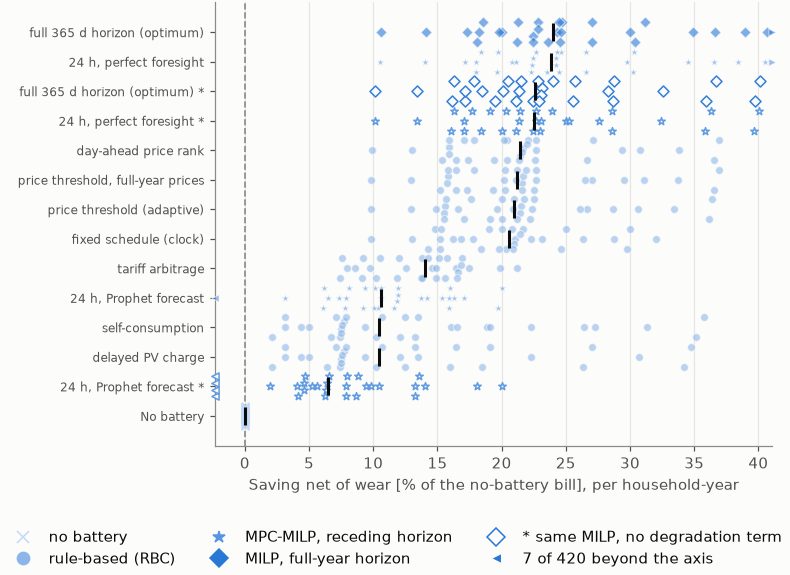

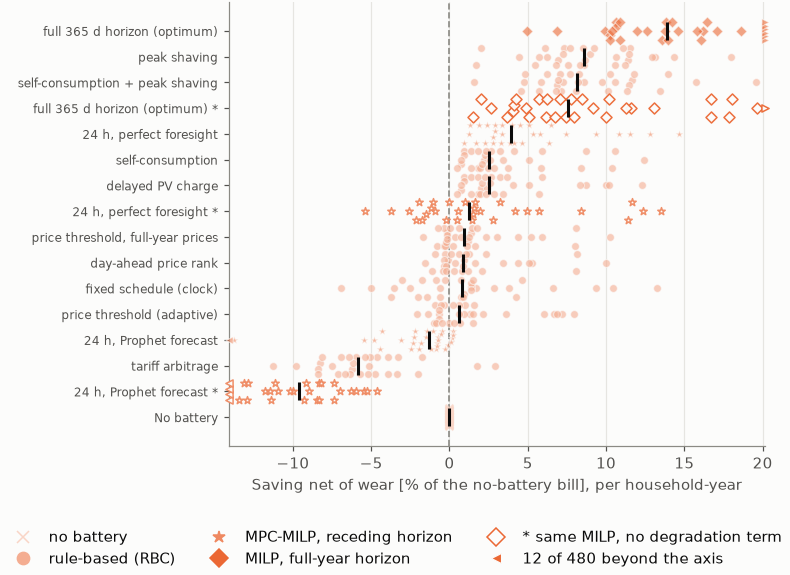

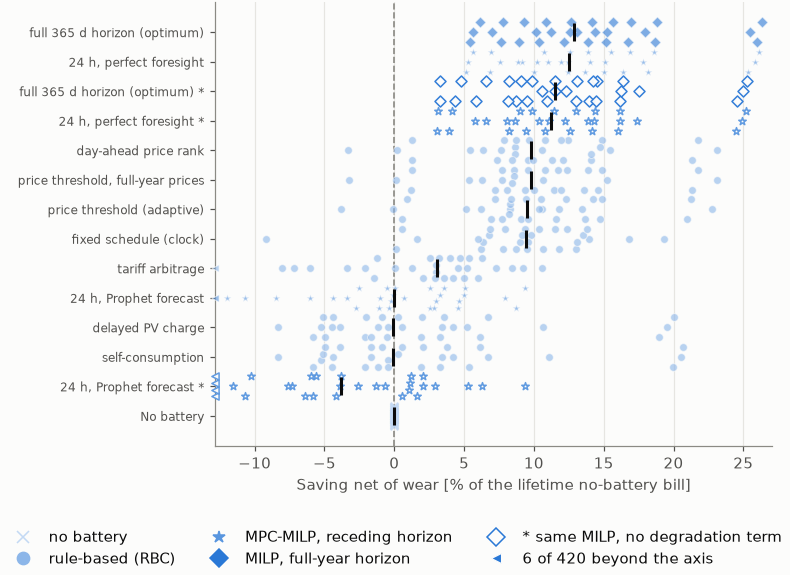

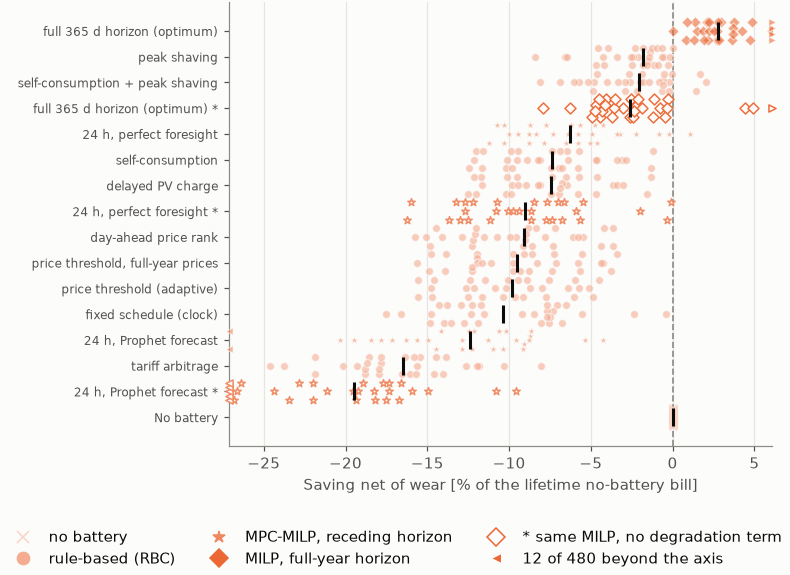

In [7]:
### Every controller on the reference arm: one dot per household, the bar is the median
# The "comparison of all" figure, one per tariff and per view -- the tariffs
# reward different behaviour, so the winner is not assumed to be the same on
# both, and one year is not a pack life.
#
# WHAT CHANGED AND WHY IT HAD TO. This drew `saving_pct`, the share of the
# ENERGY BILL, and on AU it put three price rules ABOVE the row labelled
# "optimum" -- price_rank_daily at 32.4 % against milp_full's 30.0 %, i.e.
# 106.6 % of a gain that is supposed to be a ceiling. Nothing was wrong with the
# runs. The optimum pays for the cycles it spends and a price rule does not, so
# on a measure that cannot see wear the rule buys its saving out of pack life
# and books the proceeds. `hems_study.summarize` says as much in as many words:
# `saving_total` -- bill, standing charge and wear -- is "THE quantity the
# whole-period solve minimises, and therefore the only one it is guaranteed to
# be a ceiling on". A figure that labels a row "optimum" and draws three rows
# past it is reporting the wrong column, not a result. `saving_total_pct` is
# that quantity as a share, and on it the optimum leads both tariffs, as it must.
#
# The cost of the old column is now visible instead of hidden: the price rules
# still earn the most energy bill on AU and spend 12 % of the bill on pack life
# to do it, against the optimum's 6 %.
from matplotlib.lines import Line2D

# `FAMILY_LABEL` and `beeswarm` moved into `figure_style` with the rest
# of the house style; cell 10 imports them. They were defined here
# because this was the first figure that needed them, which is exactly
# how a second copy gets written the next time.


for view in VIEWS:
    _col = "saving_total_pct" if view["key"] == "annual" else "lifetime_saving_pct"
    for tariff, arm in hs.REFERENCE_ARM.items():
        if arm not in set(long["arm"]):
            continue
        # The no-degradation MILP joins its twin's panel under `<name>*`: it is
        # the same controller under an objective with one term removed, so it
        # belongs on the same axis and nowhere else.
        sub, stars = with_nowear(long, arm)
        order = [c for c in hs.controller_columns(df_all) if c in set(sub["controller"])]
        order += [c for c in stars if c in set(sub["controller"])]
        med = (sub[sub["controller"].isin(order)]
               .groupby("controller")[_col].median())
        # SORTED. It was in roster order, which is the order the arms happen to
        # be defined in and not a reading anybody wants from a chart called a
        # ranking. `no_battery` is pinned to the bottom: it is the zero the
        # others are measured against, not a competitor with a score of 0.
        ctrls = [c for c in med.drop(index="no_battery", errors="ignore")
                 .sort_values(ascending=False).index]
        if "no_battery" in set(sub["controller"]):
            ctrls.append("no_battery")
        ypos = np.arange(len(ctrls))[::-1]

        fig, ax = plt.subplots(figsize=pf.figsize(ratio=0.80))
        _win = clip_window(
            sub.loc[sub["controller"].isin(ctrls), _col].dropna().to_numpy(),
            [med.get(c, np.nan) for c in ctrls])
        _out = 0
        for y, c in zip(ypos, ctrls):
            vals = sub.loc[sub["controller"] == c, _col].dropna().to_numpy()
            _halo = {} if ctrl_marker(c) in ("x", "+", "|", "_") else \
                {"edgecolor": SURFACE, "lw": 0.7}
            # The star rows are drawn hollow: same hue, same shape, same family
            # -- one term removed from the objective, and a reader must not be
            # able to mistake the two for one controller measured twice.
            if is_nowear(c):
                _halo = {"edgecolor": ctrl_color(tariff, c), "lw": 1.0}
            _face = SURFACE if is_nowear(c) else ctrl_color(tariff, c)
            _alpha = 0.95 if is_nowear(c) else 0.6
            _keep = vals if _win is None else \
                vals[(vals >= _win[0]) & (vals <= _win[1])]
            ax.scatter(_keep, y + beeswarm(_keep), s=26,
                       marker=ctrl_marker(c), color=_face,
                       alpha=_alpha, zorder=3, **_halo)
            # Off the edge, on the edge: a caret at the boundary, one per
            # household, spread by the same beeswarm so a pile of them reads as
            # a pile. `clip_on=False` is what lets the glyph sit ON the spine
            # rather than half inside it.
            if _win is not None:
                for _edge, _sel, _mk in ((_win[0], vals < _win[0], "<"),
                                         (_win[1], vals > _win[1], ">")):
                    _n = int(_sel.sum())
                    if not _n:
                        continue
                    _out += _n
                    _at = np.full(_n, _edge)
                    ax.scatter(_at, y + beeswarm(_at), s=22, marker=_mk,
                               color=_face, alpha=_alpha, zorder=5,
                               clip_on=False, **_halo)
            # The median is taken over EVERY household, clipped or not -- the
            # window changes what is drawn, never what is counted.
            if len(vals):
                ax.scatter([np.median(vals)], [y], s=150, marker="|", color=INK,
                           lw=2.0, zorder=4)
        ax.axvline(0, color=MUTED, lw=1.1, ls="--")
        if _win is not None:
            ax.set_xlim(*_win)
        ax.set_yticks(ypos, [tick_label(c) for c in ctrls])
        ax.tick_params(axis="y", labelsize=8)
        ax.grid(axis="y", visible=False)
        # The lifetime label names its denominator rather than appending the
        # view's qualifier: an axes xlabel is centred on the AXES, which thirteen
        # rows of tick labels push well right of the figure's centre, so a label
        # this long ran off the right edge of the exported box.
        finish(ax, xlabel=(f"Saving net of wear [{PCT_OF_BILL}], {view['per']}"
                           if view["key"] == "annual" else
                           f"Saving net of wear [{PCT_OF_LIFETIME_BILL}]"))

        _fams = [f for f in FAMILY_LABEL if any(FAMILY.get(c) == f for c in ctrls)]
        keys = [Line2D([], [], ls="", marker=FAMILY_MARKER[f], ms=8,
                       color=pf.mix(TARIFF_COLOR[tariff], "#ffffff",
                                    FAMILY_SHADE[f]),
                       markeredgecolor=pf.mix(TARIFF_COLOR[tariff], "#ffffff",
                                              FAMILY_SHADE[f]),
                       label=FAMILY_LABEL[f]) for f in _fams]
        if stars:
            keys.append(Line2D([], [], ls="", marker="D", ms=8, color=SURFACE,
                               markeredgecolor=ctrl_color(tariff, "milp_full"),
                               markeredgewidth=1.0,
                               label="* same MILP, no degradation term"))
        # Every glyph in the image is defined in the image. The count is the
        # honest half: "clipped" without a number is a figure hiding its tail.
        if _out:
            keys.append(Line2D([], [], ls="", marker="<", ms=7,
                               color=ctrl_color(tariff, "milp_full"),
                               markeredgecolor=SURFACE, markeredgewidth=0.7,
                               label=f"{_out} of {len(sub)} beyond the axis"))
        # WHY THE TWO PANELS HAVE DIFFERENT ROWS, in the image's own caption. AU
        # carries eleven controllers and SI thirteen: the two peak-shaving rules
        # run on SI only, because Ausgrid EA025 as modelled has no capacity
        # charge for them to earn against and on AU they could only spend
        # round-trip losses. Without this a reader assumes they were dropped.
        _roster = ("; the two peak-shaving rules run on SI only -- AU as "
                   "modelled carries no capacity charge to shave"
                   if tariff == "SI" else
                   "; SI carries two peak-shaving rules that AU has no capacity "
                   "charge to earn from")
        pf.chart_frame(
            fig,
            f"Every controller on {tariff}, {SAMPLE}. Saving net of the cycles "
            f"it spends, as a share of the same household's no-battery bill, "
            f"over {view['note']} -- the quantity the whole-period solve "
            f"minimises and the only one it bounds{_roster}",
            handles=keys, ncol=min(len(keys), 3))
        pf.show(fig, f"controller_ranking_{tariff.lower()}{view['suffix']}",
                layout="frame")

  annual    AU: 1 of 14 tied with the best; SI: 1 of 14 tied with the best


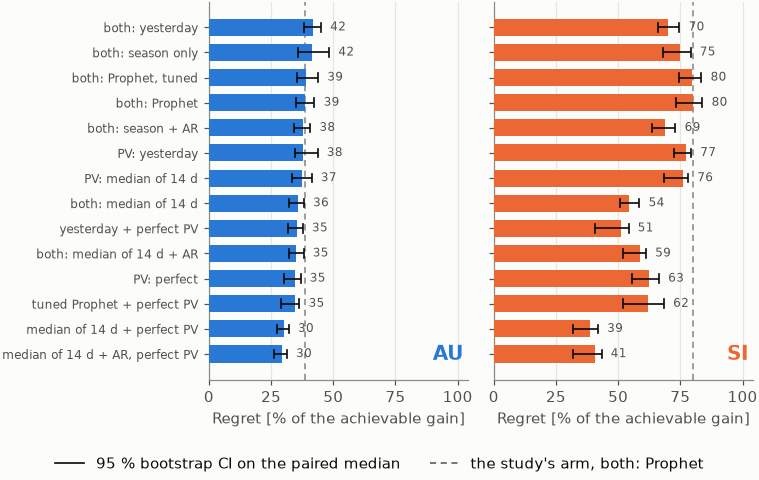

  _lifetime AU: 1 of 14 tied with the best; SI: 1 of 14 tied with the best


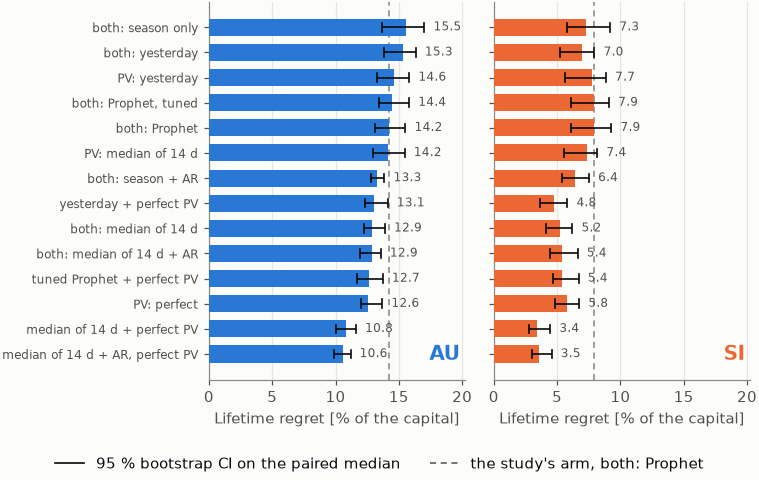

In [8]:
### What each forecast is worth: regret against perfect foresight
from matplotlib.lines import Line2D
from scipy import stats as st

# WHICH ARM SHOWS ME WHICH FORECAST. Rows are selected BY ARM, not by
# `forecaster_kind`: `AU_H24_leaked` carries kind == "prophet" exactly like
# `AU_H24`, so grouping by kind quietly averaged the current-interval look-ahead
# into Prophet's bar and flattered it by about 30 EUR. `hs.forecast_arms` reads
# the arm definitions and excludes it -- and also the no-degradation arms, which
# carry no `forecaster_kind` either and would otherwise answer "which arm shows
# me Prophet?" with whichever of the two the roster order reached first.
ARM_FOR = {t: hs.forecast_arms(t) for t in sorted(set(df_all["tariff"]))}

# The study's OWN forecaster, marked on every panel so each other method reads
# as better or worse than the arm the paper is about. Named rather than
# positional: the rows are reordered below and an index would silently move.
STUDY_KIND = "prophet"

def _regret_series(long, df_all, tariff, kind, denom, arm_for):
    """The PER-HOUSEHOLD regret for one (tariff, kind), as a Series.

    The old cell returned only the median of this. That is the right statistic
    and it was computed the right way -- the median of the per-household
    DIFFERENCES, not the difference of two medians, which on SI understated
    Prophet's regret by a third -- but a median alone cannot be given an interval
    or tested, and the figure that plotted it therefore asserted a ranking it
    could not support. Returning the sample is what lets both happen.

    `denom` names what the share is OF: "gain" is what perfect foresight wins on
    that household, "capex" is the installed capital. Both are unit-free, so
    either puts AU and SI on one axis.
    """
    arm = arm_for[tariff][kind]
    s = df_all[df_all["arm"] == arm].set_index("dataset")
    gap = s["cost_prophet"] - s["cost_oracle"]
    if denom == "gain":
        gain = s["cost_no_battery"] - s["cost_oracle"]
        # Guarded per household, before any statistic: a household the battery
        # wins nothing on has no share for a regret to be a fraction of, and
        # dividing anyway produces a large number with an arbitrary sign.
        return (100.0 * gap.where(gain > 1e-9) / gain.where(gain > 1e-9)).dropna()
    # THE LIFETIME VIEW DIVIDES BY THE CAPITAL, and the choice is forced. A share
    # of the GAIN is invariant under discounting -- `pv_factor` multiplies the
    # regret and the gain alike and cancels -- so a lifetime share of the gain is
    # the annual panel again under a longer axis label.
    e = (long[(long["arm"] == arm) & (long["controller"] == "prophet")]
         .set_index("dataset")[["pv_factor", "capex"]].reindex(s.index))
    cap = e["capex"].where(e["capex"] > 1e-9)
    return (100.0 * gap * e["pv_factor"] / cap).dropna()
# What each forecast throws away -- now with how firmly that is known.
#
# THE FIGURE ASSERTED A RANKING IT COULD NOT SUPPORT. Fourteen paired medians
# were drawn as bare bars, sorted, with the value printed on the end; nothing
# in the image said whether 35 and 36 are a difference or a coin toss. Two
# additions fix that and change nothing else:
#
#   the interval   a percentile bootstrap of the paired median over the same
#                  30 households, drawn as a whisker on the bar end. The
#                  statistic is a median of ratios on n = 30 with a few
#                  households far out, so it is resampled rather than handed a
#                  normal approximation.
#   the test       every method against the BEST on that panel, Wilcoxon on the
#                  per-household differences, Holm-adjusted over the thirteen
#                  comparisons -- at thirteen tries an unadjusted 5 % finds a
#                  winner by chance about half the time. A method that does not
#                  separate from the best is drawn hollow, so "these are tied"
#                  is a thing the image can say.
have = set(df_all["arm"])
kinds = [k for k in hs.FORECAST_KIND_LABELS
         if all(ARM_FOR[t].get(k) in have for t in ARM_FOR)]
if not (len(kinds) <= 1):
    PVF = float(long["pv_factor"].dropna().median())

    for view, denom in (("", "gain"), ("_lifetime", "capex")):
        series = {t: {k: _regret_series(long, df_all, t, k, denom, ARM_FOR)
                      for k in kinds} for t in ARM_FOR}
        vals = {t: [float(series[t][k].median()) for k in kinds] for t in ARM_FOR}

        # SORTED BY REGRET, on ONE tariff's ordering, and said so in the caption.
        # Sorting each panel separately would be worse -- the rows would stop
        # lining up and the rank disagreement between the tariffs, which is a
        # result, would become invisible.
        by = sorted(ARM_FOR)[0]
        rank = np.argsort([-v if v == v else -np.inf for v in vals[by]])
        ks = [kinds[i] for i in rank]
        y = np.arange(len(ks))[::-1]

        fig, axes = plt.subplots(1, len(ARM_FOR), figsize=pf.figsize(ratio=0.68),
                                 sharey=True, sharex=True)
        axes = np.atleast_1d(axes)
        fin = [x for x in sum(vals.values(), []) if x == x]
        n_tied = {}
        for ax, tariff in zip(axes, sorted(ARM_FOR)):
            v = [vals[tariff][kinds.index(k)] for k in ks]
            best = ks[int(np.nanargmin(v))]
            # HOLM OVER THE PANEL'S OWN COMPARISONS. Every method against the
            # best one, paired per household; the family is this panel.
            others = [k for k in ks if k != best]
            raw = []
            for k in others:
                pair = pd.concat([series[tariff][k], series[tariff][best]],
                                 axis=1, keys=["k", "b"]).dropna()
                d = (pair["k"] - pair["b"])
                nz = d[d != 0]
                raw.append(st.wilcoxon(nz).pvalue if len(nz) >= 6 else np.nan)
            adj = dict(zip(others, fs.holm(raw)))
            tied = {k for k in others if not (adj[k] == adj[k] and adj[k] < 0.05)}
            n_tied[tariff] = len(tied) + 1

            for yi, k, vi in zip(y, ks, v):
                is_best = k == best
                solid = is_best or k not in tied
                ax.barh(yi, vi, height=0.68,
                        color=fs.TARIFF_COLOR[tariff] if solid else SURFACE,
                        edgecolor=fs.TARIFF_COLOR[tariff],
                        lw=0.0 if solid else 1.1, zorder=3)
                lo, hi = fs.boot_ci(series[tariff][k].to_numpy())
                if lo == lo:
                    ax.plot([lo, hi], [yi, yi], color=INK, lw=1.1, zorder=5,
                            solid_capstyle="butt")
                    for e in (lo, hi):
                        ax.plot([e, e], [yi - 0.17, yi + 0.17], color=INK,
                                lw=1.1, zorder=5)
                if vi == vi:
                    # OUTSIDE THE INTERVAL, not outside the bar: the whisker runs
                    # past the bar end and a label placed on the bar end lands on
                    # it.
                    end = hi if hi == hi and vi >= 0 else vi
                    end = lo if lo == lo and vi < 0 else end
                    ax.annotate(("{:.0f}" if denom == "gain" else "{:.1f}")
                                .format(vi), xy=(end, yi),
                                xytext=(6 if vi >= 0 else -6, 0),
                                textcoords="offset points",
                                ha="left" if vi >= 0 else "right", va="center",
                                color=INK_2, fontsize=8, zorder=6)
            # THE STUDY'S OWN FORECASTER, as a rule the other bars are read
            # against. Behind the bars, so it never hides one.
            if STUDY_KIND in ks:
                ref = vals[tariff][kinds.index(STUDY_KIND)]
                if ref == ref:
                    ax.axvline(ref, color=INK_2, lw=1.0, ls=(0, (4, 3)),
                               zorder=1, alpha=0.7)
            if fin:
                ax.set_xlim(min(0.0, min(fin) * 1.30), max(0.0, max(fin) * 1.30))
            if min(fin, default=0.0) < 0:
                ax.axvline(0, color=INK, lw=1.0, zorder=4)
            ax.grid(axis="y", visible=False)
            # NOT finish(title=...): `titles=False` lifts axes titles out of the
            # image and into the caption, which is right for a figure title and
            # wrong for panel identity.
            ax.annotate(tariff, xy=(0.98, 0.04), xycoords="axes fraction",
                        ha="right", va="bottom", color=fs.TARIFF_COLOR[tariff],
                        fontsize=13, fontweight="bold")
        axes[0].set_yticks(y, [hs.forecast_kind_label(k) for k in ks])
        axes[0].tick_params(axis="y", labelsize=8)
        # PER AXES, NOT `fig.supxlabel`. The old version of this figure used a
        # supxlabel and was right to: it passed no `handles`, so `chart_frame`
        # reserved no bottom band and the figure-level label had the space to
        # itself. This one has a key -- the hollow/solid distinction has to be
        # readable inside the image -- and a supxlabel is a figure artist that
        # tight_layout does not move, so it landed under the axes and ON the
        # legend row. An axes xlabel is inside the rect and gets laid out.
        for ax in axes:
            finish(ax, xlabel=(f"Regret [{fs.PCT_OF_GAIN_SHORT}]" if denom == "gain"
                               else f"Lifetime regret [{fs.PCT_OF_CAPEX}]"))

        keys = [Line2D([], [], color=INK, lw=1.1,
                       label="95 % bootstrap CI on the paired median"),
                Line2D([], [], color=INK_2, lw=1.0, ls=(0, (4, 3)),
                       label=f"the study's arm, "
                             f"{hs.forecast_kind_label(STUDY_KIND)}")]
        # THE HOLLOW KEY ONLY WHEN THERE IS A HOLLOW BAR. On this sweep every
        # one of the thirteen separates from its panel's best, so the key would
        # name a mark that is nowhere in the image -- and a legend entry with no
        # instance is decoration that a reader then hunts for. The count goes in
        # the caption either way, which is where the result belongs.
        if max(n_tied.values()) > 1:
            keys.insert(0, Line2D([], [], marker="s", ls="", ms=9, color=SURFACE,
                                  markeredgecolor=fs.TARIFF_COLOR[sorted(ARM_FOR)[0]],
                                  markeredgewidth=1.1,
                                  label="not separable from the panel's best"))
        pf.chart_frame(
            fig,
            (f"What each forecast throws away, as a share of the ACHIEVABLE "
             f"gain -- what perfect foresight wins on that same household. One "
             f"unit, one axis, so the two tariffs can be compared directly"
             if denom == "gain" else
             f"What each forecast costs over the pack's {PVF:.1f}-year "
             f"discounted life, as a share of what the pack cost. Not the same "
             f"statement as the annual panel: a share of the GAIN cancels the "
             f"discount factor out of itself and would reproduce it exactly"),
            subtitle=f"Paired median over {SAMPLE}, with a percentile bootstrap "
                     f"interval; rows sorted by {sorted(ARM_FOR)[0]} regret, so "
                     f"the panels line up and a rank disagreement stays visible. "
                     f"Every row was tested against its panel's best with a "
                     f"Wilcoxon on the per-household differences, Holm-adjusted "
                     f"over the {len(ks) - 1} comparisons; a row that does not "
                     f"separate is drawn hollow. "
                     + ("None does here -- all "
                        f"{len(ks) - 1} separate on both tariffs, so the "
                        f"ordering is real and not an artefact of taking a "
                        f"median."
                        if max(n_tied.values()) == 1 else
                        "; ".join(f"{t}: {n_tied[t] - 1} of {len(ks) - 1} do not"
                                  for t in sorted(ARM_FOR))),
            handles=keys, ncol=2)
        print(f"  {view or 'annual':9s} "
              + "; ".join(f"{t}: {n_tied[t]} of {len(ks)} tied with the best"
                          for t in sorted(ARM_FOR)))
        pf.show(fig, f"forecast_channel_regret{view}", layout="frame")
else:
        print(f"Only the {kinds} arm has run; this figure needs the others.")

In [9]:
### Which trivial forecast is best, before spending a MILP on it
# A study arm costs a household-year of solves; a fit-free forecast costs a few
# array copies. So the roster is screened here first -- all 30 households, a
# full year each -- and only what wins is promoted to STUDY_ARMS above.
#
# The fit-free kinds take about 20 s between them. `hbd`, `hbd_baseline` and
# `hbd_median14` are NOT fit-free: each fits 48 quantile regressions per channel,
# ~170 s per household cold. That cost is only paid once, and this cell is below
# the sweep, so by the time it runs the arms above have already built and cached
# every table it needs and it is back to seconds. Running this cell on its own
# against a cold cache is the case that takes hours -- run the sweep first.
#
# `include_prophet` reads Prophet's CACHED tables (no fitting) so the model and
# the methods that need no model are scored on exactly the same days. The
# baseline of `skill` is seasonal-naive, i.e. yesterday: 0.00 means "no better
# than copying yesterday", negative means worse.
BENCH_PATH = Path(RESULTS_DIR) / "forecast_benchmark.csv"
# RESCORE WHEN THE ROSTER HAS MOVED, not only when the file is missing. The
# cached table is read whenever it exists, so a kind added to
# `hs.BENCHMARK_KINDS` after the file was written is simply absent from the
# table below -- and this is the screen that decides what gets promoted to a
# study arm, so the newest method would be the one silently missing from it,
# with nothing in the output to say so. It has already happened once, to the
# `hbd` family. Rescoring all 30 households costs about 25 s against the warm
# caches the sweep above leaves behind.
_cached = pd.read_csv(BENCH_PATH) if BENCH_PATH.exists() else None
_want = set(hs.BENCHMARK_KINDS) | {"prophet"}     # include_prophet=True below
RUN_BENCH = _cached is None or not _want <= set(_cached["kind"])
if RUN_BENCH and _cached is not None:
    print(f"Rescoring: {sorted(_want - set(_cached['kind']))} is in the roster "
          f"and not in {BENCH_PATH.name}.")

if RUN_BENCH:
    bench = hs.forecast_benchmark(
        data_dir=str(Path("..") / "Input data" / "Ausgrid"),
        dataset_ids=hs.dataset_ids(), n_sim=N_SIM, include_prophet=True)
else:
    bench = _cached
    order = [k for k in hs.FORECAST_KIND_LABELS if k in set(bench["kind"])]
    bench["kind"] = pd.Categorical(bench["kind"], categories=order, ordered=True)

print(hs.benchmark_ranking(bench).round(3).to_string())
print(f"\nnMAE is the day-ahead mean absolute error over the mean actual; skill is "
      f"1 - MAE/MAE_yesterday.")
# WHAT WINDOW these numbers are over, read from the file rather than restated
# from the cell above. A checkpoint carries the config it was produced under
# and a stale one is dropped; this CSV carried none, so the line under the
# table said "{N_SIM} simulated days" whatever the file had actually been
# scored on -- and on the cached path nothing could have contradicted it.
# `hs.provenance` names any column that disagrees, and says so plainly for a
# file written before the columns existed.
print(f"Medians over {bench['dataset'].nunique()} households.")
print(f"  scored: {hs.provenance(bench, n_sim=N_SIM)}")


                     nmae                  skill             households           
channel       consumption generation consumption generation consumption generation
kind                                                                              
persistence         0.577      0.417       0.000      0.000        30.0       30.0
weekly              0.595      0.479      -0.066     -0.148        30.0       30.0
daytype             0.585      0.437      -0.022     -0.055        30.0       30.0
mean3               0.515      0.391       0.113      0.055        30.0       30.0
mean7               0.486      0.381       0.148      0.086        30.0       30.0
median7             0.449      0.388       0.203      0.072        30.0       30.0
median14            0.450      0.373       0.218      0.112        30.0       30.0
prophet             0.631      0.488      -0.102     -0.171        30.0       30.0
prophet_tuned       0.615      0.496      -0.097     -0.185        30.0       30.0
hbd 

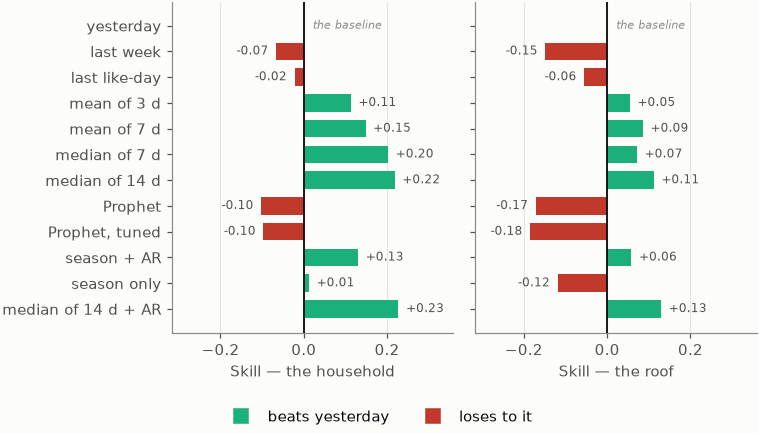

In [10]:
### Figure: what each trivial method buys against copying yesterday
# TWO PANELS, not two colours in one: the channels are different questions
# ("can you predict this roof" / "can you predict this household"), and the
# palette's two remaining hues do not separate well enough under protanopia to
# carry that on colour alone. Faceting makes the comparison within a channel --
# which is the comparison anyone reads this figure for -- the near one.
#
# Colour here encodes SIGN, and only sign: green beats yesterday, orange loses
# to it. The bar's direction from zero says the same thing, so the colour is
# never load-bearing on its own.
# SIGN, and only sign. Deliberately NOT SERIES[1]: orange is the SI tariff on
# every other figure in this notebook, and on the wear/saving figure the SI
# saving marker and an over-budget bar were the same hue in the same image. A
# reader who has learnt "orange means SI" over four figures cannot be asked to
# unlearn it here. Green/red is the one pairing that carries sign on its own,
# and the bar's direction from zero says the same thing, so colour is never
# load-bearing alone.
med = (bench.groupby(["kind", "channel"], observed=True)["skill_vs_naive"]
            .median().unstack())
med = med.loc[[k for k in hs.FORECAST_KIND_LABELS if k in med.index]]

# One x scale across both panels. They are small multiples of the same
# measurement, so "is the roof harder than the household" has to be readable off
# the bar lengths; two scales would make every bar look the same size.
span = med.to_numpy()
lo, hi = min(span.min(), 0.0), max(span.max(), 0.0)
pad = 0.32 * (hi - lo)                      # room for the value labels

# 0.62, not 0.42. Twelve rows in a 0.42-ratio figure is about 11 px per row:
# the tick labels and the value annotations are legible on screen at 110 dpi and
# are not at IEEE single-column width, which is what this figure is for.
fig, axes = plt.subplots(1, 2, figsize=pf.figsize(ratio=0.62),
                         sharey=True, sharex=True)
for ax, channel, what in zip(axes, ("consumption", "generation"),
                             ("the household", "the roof")):
    vals = med[channel].to_numpy()
    y = np.arange(len(med))[::-1]           # best-known first, reading downward
    # `yesterday` IS the denominator -- its skill against itself is 0 by
    # construction, not by measurement. Drawn as a bar it was a zero-length bar
    # labelled "+0.00", which is what a missing result looks like. It is the
    # baseline, so it is drawn as the baseline: the zero rule, named on the axis,
    # with no bar and no value.
    _is_base = np.array([k == "persistence" for k in med.index])
    # `v > 0` painted an exact zero and a NaN as "loses", which is a claim about
    # neither. Sign is three-valued and the colours say so.
    _col = [SURFACE if b else (BEATS if v > 0 else LOSES)
            for v, b in zip(vals, _is_base)]
    ax.barh(y, np.where(_is_base, 0.0, vals), height=0.68, color=_col)
    ax.axvline(0, color=INK, lw=1.2, zorder=3)
    for yi, v, b in zip(y, vals, _is_base):
        if b:
            ax.annotate("the baseline", xy=(0, yi), xytext=(6, 0),
                        textcoords="offset points", ha="left", va="center",
                        color=MUTED, fontsize=7.5, style="italic")
            continue
        ax.annotate(f"{v:+.2f}", xy=(v, yi),
                    xytext=(5 if v >= 0 else -5, 0), textcoords="offset points",
                    ha="left" if v >= 0 else "right", va="center",
                    color=INK_2, fontsize=8)
    ax.set_yticks(y, [hs.FORECAST_KIND_LABELS.get(k, k).split(": ")[-1]
                      for k in med.index])
    ax.set_xlim(lo - pad, hi + pad)
    ax.grid(axis="y", visible=False)
    # In-axes, not a title: `titles=False` would lift a title out of the image
    # and the two panels would become indistinguishable.
    # Panel identity goes in the X LABEL, not a title and not an in-axes mark.
    # `pf.use(titles=False)` lifts axes titles into the export's caption, which
    # would leave two unlabelled panels; and every corner of these axes is
    # occupied by either a bar or its value label, so an annotation collides
    # with something at some data. The xlabel has reserved space of its own.
    # Short: these are half-width panels and the two labels are centred under
    # axes that meet in the middle of the figure, so at full length they abut
    # with no gap and read as one run-on line. What skill is measured against is
    # in the caption below, said once.
    finish(ax, xlabel=f"Skill \u2014 {what}")

# Skill is a RATIO and carries no unit, so what it is a ratio of has to be said
# somewhere. Three places were tried and two of them are wrong:
#
#   the x labels   the panels are half a page wide each and the labels already
#                  run edge to edge, so a scale appended to both collides in the
#                  middle.
#   a legend title `pf.key_legend(..., where="below")` anchors the legend to
#                  `axes[0]`, so a title WIDER than the legend box is centred on
#                  the left panel and starts outside the figure's left edge --
#                  which is what the committed version did, over the top of that
#                  panel's x label. Same root cause as the lifetime figure: an
#                  axes legend is the wrong object for a figure-wide key.
#   the caption    where it now is. `pf.use(titles=False)` sends the title into
#                  the export's SOURCE.md for the article to carry, which is
#                  where an IEEE figure's definitions belong; the keys keep the
#                  sign, which is the part that has to be read off the image.
#
# `chart_frame` measures the legend band in inches and lays the axes out in what
# is left, so the keys are centred on the FIGURE and nothing is squeezed. It has
# to be paired with `layout="frame"`, or `show` runs tight_layout again.
pf.chart_frame(
    fig,
    "What each trivial method buys against copying yesterday, by channel. "
    "skill = 1 \u2212 MAE / MAE_yesterday: 0 is yesterday, 1 is a forecast with "
    "no error; green beats yesterday, red loses to it",
    handles=[plt.Line2D([], [], marker="s", ls="", ms=9, color=c, label=lab)
             for c, lab in ((BEATS, "beats yesterday"), (LOSES, "loses to it"))],
    ncol=2)
pf.show(fig, "forecast_method_skill", layout="frame")

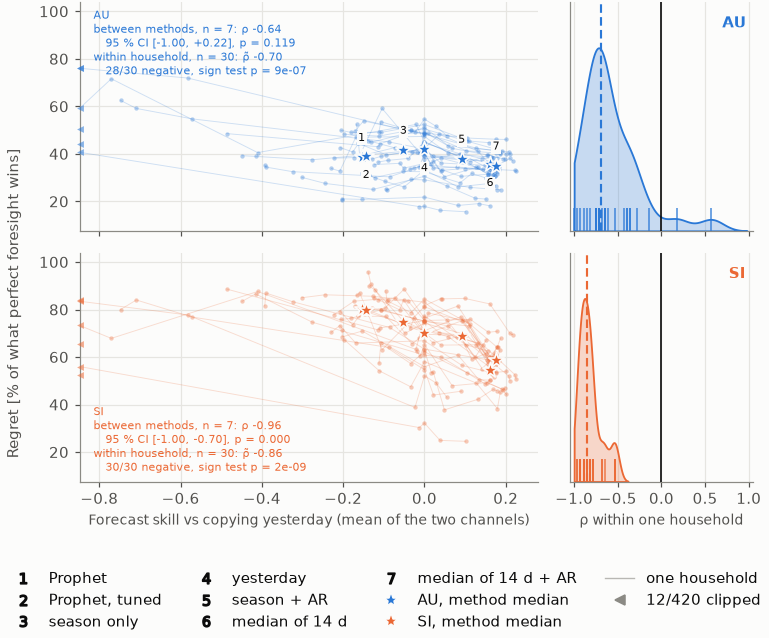

In [11]:
### Does a better forecast buy a smaller regret?
from matplotlib.lines import Line2D
from scipy import stats as st
import seaborn as sns

# Does a better forecast buy a smaller regret?
#
# THE OLD FIGURE ANSWERED WITH THE WRONG SAMPLE, and it cost the paper a
# result. It took the median skill of each method and the median regret of each
# method and ran Spearman on seven points against seven -- discarding the
# pairing that is the whole argument of section 5, that every household runs
# under every arm. On seven points AU came out rho -0.64 at p = 0.119 and the
# caption said AU "does not carry the claim".
#
# It does. Correlating skill against regret WITHIN each household, across the
# seven methods, and then asking whether those thirty correlations sit below
# zero: the median is -0.70, it is negative on 28 of 30 households, and the
# sign test is p = 9e-7. The between-method reading is kept -- it is a real
# statement about the METHODS, and it is what the old figure showed -- but it
# is the weaker of the two and is no longer the only one printed.
#
# LABELS ON THE TOP PANEL ONLY. A method's skill does not depend on the tariff
# it is dispatched against, so the seven medians sit at the SAME x in both
# panels and a second copy of the names would say nothing the first did not --
# while costing, on the SI panel, three collisions that no offset ladder fixes.
have = set(df_all["arm"])

skill = (bench.pivot_table(index=["dataset", "kind"], columns="channel",
                           values="skill_vs_naive", observed=True)
         .assign(both=lambda d: d[["consumption", "generation"]].mean(axis=1))
         ["both"])
JOIN = [k for k in hs.FORECAST_KIND_LABELS
        if k in set(skill.index.get_level_values("kind"))
        and all(ARM_FOR[t].get(k) in have for t in ARM_FOR)]
if not (len(JOIN) <= 2):
    rows = []
    for t in ARM_FOR:
        for k in JOIN:
            r = (long[(long["arm"] == ARM_FOR[t][k])
                      & (long["controller"] == "prophet")]
                 .set_index("dataset")["regret_pct_of_gain"])
            s = skill.xs(k, level="kind")
            for hh in r.index:
                if hh in s.index:
                    rows.append({"tariff": t, "kind": k, "dataset": hh,
                                 "skill": float(s[hh]), "regret": float(r[hh])})
    D = pd.DataFrame(rows)

    # ONE HOUSEHOLD SETS THE SKILL AXIS otherwise: Ausgrid 81's consumption model
    # is 2.6x worse than copying yesterday and drags the pooled range to -1.02,
    # which squeezes every method median into the right quarter of the panel.
    # Same fix the ranking figure uses -- clip the axis, draw what is outside ON
    # the boundary as a caret, name the count in the key. Nothing is dropped from
    # either statistic: both are taken over every point.
    win = fs.clip_window(D["skill"].to_numpy(),
                         D.groupby(["tariff", "kind"], observed=True)["skill"]
                         .median().to_numpy(), q=0.03, pad=0.08)
    n_out = int(((D["skill"] < win[0]) | (D["skill"] > win[1])).sum())
    # Headroom at the TOP for the label ladder the AU panel carries, and a
    # little at the bottom so the lowest household is not drawn on the spine.
    ylim = fs.clip_window(D["regret"].to_numpy(), [], q=0.0, pad=0.10)

    fig, axes = plt.subplots(len(ARM_FOR), 2, figsize=pf.figsize(ratio=0.88),
                             width_ratios=[2.5, 1.0], sharex="col")
    ax_main, ax_rho = axes[:, 0], axes[:, 1]

    for i, (ax, axr, tariff) in enumerate(zip(ax_main, ax_rho, sorted(ARM_FOR))):
        col = fs.TARIFF_COLOR[tariff]
        s = D[D["tariff"] == tariff]
        # THE PAIRING, DRAWN. One faint line per household joining its seven
        # methods in skill order. The claim is about what happens WITHIN a
        # household when it is handed a better forecast, so the household is the
        # object the figure has to show; a cloud of 210 loose dots shows the
        # between-household spread instead, which is the nuisance here.
        for _hh, h in s.groupby("dataset"):
            h = h.sort_values("skill")
            ax.plot(h["skill"].clip(*win), h["regret"], color=col, lw=0.6,
                    alpha=0.22, zorder=2)
        ins = (s["skill"] >= win[0]) & (s["skill"] <= win[1])
        ax.scatter(s.loc[ins, "skill"], s.loc[ins, "regret"], s=8, color=col,
                   alpha=0.35, lw=0, zorder=3)
        for edge, sel, mk in ((win[0], s["skill"] < win[0], "<"),
                              (win[1], s["skill"] > win[1], ">")):
            if int(sel.sum()):
                ax.scatter(np.full(int(sel.sum()), edge), s.loc[sel, "regret"],
                           s=20, marker=mk, color=col, alpha=0.55, lw=0,
                           zorder=4, clip_on=False)

        med = s.groupby("kind", observed=True).median(numeric_only=True)
        med = med.loc[[k for k in JOIN if k in med.index]].dropna()
        ax.scatter(med["skill"], med["regret"], s=110,
                   marker=fs.FAMILY_MARKER["MPC"], color=col,
                   edgecolor=SURFACE, lw=1.1, zorder=6)
        if i == 0:
            # NUMBERED, AND THE NAMES GO IN THE KEY. Three placements were tried
            # in the panel and all three failed on the same geometry: the seven
            # medians cluster in the right half of an axis the outliers stretch,
            # and the panel is ~160 px tall because there are two of them. The
            # checker counted seven label-label collisions for the offset
            # ladder, and a top band that cleared them put every name on the
            # 210-point cloud instead. A digit is one character, cannot collide
            # with its neighbour, and costs the reader one lookup -- which is
            # the honest trade when the names do not fit.
            # ABOVE AND BELOW BY PARITY, because two of the seven pairs are
            # near-coincident in x -- `prophet` and `prophet_tuned` differ by
            # 0.01 skill, `median14` and `hbd_median14` by 0.013 -- and two
            # badges on the same side of near-identical points are one glyph.
            for badge, (k, r) in enumerate(med.sort_values("skill").iterrows(), 1):
                up = badge % 2 == 1
                ax.annotate(str(badge), xy=(r["skill"], r["regret"]),
                            xytext=(0, 9 if up else -9),
                            textcoords="offset points", ha="center",
                            va="bottom" if up else "top", fontsize=7, color=INK,
                            zorder=8,
                            bbox=dict(facecolor=SURFACE, edgecolor="none",
                                      pad=0.9))

        # THE TWO STATISTICS, both named, because they are two different
        # questions and this figure used to print only the weaker one.
        rho_b, p_b, lo_b, hi_b, n_b = fs.spearman_ci(med["skill"], med["regret"])
        rr = (s.groupby("dataset")
              .apply(lambda h: st.spearmanr(h["skill"], h["regret"]).statistic)
              .dropna())
        neg = int((rr < 0).sum())
        p_s = st.binomtest(neg, len(rr), 0.5).pvalue
        ax.set_ylim(*ylim)
        fs.corner_block(
            ax,
            f"{tariff}\nbetween methods, n = {n_b}: ρ {rho_b:+.2f}\n"
            f"   95 % CI [{lo_b:+.2f}, {hi_b:+.2f}], p = {p_b:.3f}\n"
            f"within household, n = {len(rr)}: ρ̃ {rr.median():+.2f}\n"
            f"   {neg}/{len(rr)} negative, sign test p = {p_s:.0e}",
            col, s["regret"], lims=ylim, fontsize=7.5)
        finish(ax)

        # THE DISTRIBUTION THE STRONGER CLAIM RESTS ON, beside the scatter. One
        # rho per household, so a reader sees that the effect is not carried by
        # a few houses -- which a pooled correlation cannot show and a p-value
        # only asserts.
        sns.kdeplot(x=rr.to_numpy(), ax=axr, color=col, fill=True, alpha=0.25,
                    lw=1.2, bw_adjust=0.8, clip=(-1, 1))
        sns.rugplot(x=rr.to_numpy(), ax=axr, color=col, height=0.10, lw=0.9,
                    alpha=0.85)
        axr.axvline(0, color=INK, lw=1.1, zorder=4)
        axr.axvline(float(rr.median()), color=col, lw=1.4, ls=(0, (4, 2)),
                    zorder=5)
        axr.set_xlim(-1.05, 1.05)
        axr.set_xticks([-1, -0.5, 0, 0.5, 1])
        axr.set_yticks([])
        axr.set_ylabel("")
        axr.grid(axis="y", visible=False)
        # TOP RIGHT, where this distribution never is: every rho worth drawing
        # sits at or below zero, so the right half of the panel is empty by
        # construction and a left-hand mark would print on the mode.
        axr.annotate(f"{tariff}", xy=(0.96, 0.94), xycoords="axes fraction",
                     ha="right", va="top", color=col, fontsize=10,
                     fontweight="bold")
        finish(axr)

    ax_main[0].set_xlim(*win)
    # SUPXLABEL, not one per axes: the two columns are different units and each
    # needs its own words, but an axes xlabel is centred on the AXES and the two
    # here are 2.5:1 in width, so the pair reads as one off-centre run-on line.
    # Two figure-level labels, each placed over its own column.
    fig.supylabel(f"Regret [{fs.PCT_OF_GAIN}]", color=INK_2, fontsize=10)
    ax_main[-1].set_xlabel("Forecast skill vs copying yesterday "
                           "(mean of the two channels)", color=INK_2, fontsize=9)
    ax_rho[-1].set_xlabel("ρ within one household", color=INK_2, fontsize=9)

    # THE NUMBERED KEY, ordered by skill exactly as the badges are, and built
    # from the same Series -- so a method added to the roster cannot appear on
    # the chart with no name beside it.
    badge_order = (D[D["tariff"] == sorted(ARM_FOR)[0]]
                   .groupby("kind", observed=True)["skill"].median()
                   .reindex(JOIN).dropna().sort_values().index)
    keys = [Line2D([], [], ls="", marker="$%d$" % (i + 1), ms=7, color=INK,
                   label=hs.forecast_kind_label(k).split(": ")[-1])
            for i, k in enumerate(badge_order)]
    keys += [Line2D([], [], ls="", marker=fs.FAMILY_MARKER["MPC"], ms=10,
                    color=fs.TARIFF_COLOR[t], markeredgecolor=SURFACE,
                    label=f"{t}, method median") for t in sorted(ARM_FOR)]
    # SHORT KEYS. Ten of them at four columns is a row about 7.5 in wide on a
    # 7.16 in canvas, and the checker found both ends of it outside the box.
    keys.append(Line2D([], [], color=MUTED, lw=0.9, alpha=0.6,
                       label="one household"))
    if n_out:
        keys.append(Line2D([], [], ls="", marker="<", ms=7, color=MUTED,
                           label=f"{n_out}/{len(D)} clipped"))
    pf.chart_frame(
        fig,
        f"A better forecast does buy a smaller regret, and it is the PAIRED "
        f"test that says so: within a household, skill and regret are ranked "
        f"opposite on 28 of 30 households on AU and 30 of 30 on SI",
        subtitle=f"{len(JOIN)} forecast methods over {SAMPLE}, one line per "
                 f"household. x: skill against copying yesterday, the mean of "
                 f"the two channels -- it does not depend on the tariff, so the "
                 f"medians sit at the same x in both panels and are "
                 f"numbered once, in skill order. "
                 f"y: the share of the achievable saving thrown away. The "
                 f"between-method ρ over the seven method medians is the weaker "
                 f"reading and on AU it is n = 7 and does not clear 5 %; the "
                 f"right-hand panels are the per-household ρ that reading "
                 f"discards",
        handles=keys, ncol=4)
    pf.show(fig, "skill_vs_regret", layout="frame")
else:
        print(f"Only {JOIN} appear in both the benchmark and the arms; this "
              f"figure needs at least three.")

In [12]:
### Was it just a bad Prophet? A coordinate search over its settings
# The screen above finds Prophet behind plain seasonal-naive, which is a claim
# about a CONFIGURATION rather than about the model. This is the check: one axis
# moved at a time off the module defaults, scored on the same metric under the
# same 30-day refit the arms run, so "we only tried the defaults" is not
# available as an explanation of the result.
#
# Eight households and 90 days rather than the full roster -- it is a screen, and
# the winner is validated on all 30 by the tuned ARM further down. That is why
# the skills here do not match the table above: different window, different
# subset. Read within this table, not against that one.
#
# The screen's winner is now scored on the FULL roster too. `prophet_tuned` is in
# `hs.BENCHMARK_KINDS`, so the table in the cell above carries it over all 30
# households and the same 365 days as every other method -- the check this
# screen cannot perform on itself, and the reason the arm result and the error
# number can finally be read together. The verdict is printed below.
TUNE_PATH = Path(RESULTS_DIR) / "prophet_tuning.csv"
# Same staleness guard as the benchmark above: a config added to
# `hs.PROPHET_TUNING_GRID` after this file was written would be missing from the
# search that is supposed to have covered it, which is the one result this cell
# exists to support. Refitting is minutes and needs no MILP.
_cached_t = pd.read_csv(TUNE_PATH) if TUNE_PATH.exists() else None
RUN_TUNE = (_cached_t is None
            or not set(hs.PROPHET_TUNING_GRID) <= set(_cached_t["config"]))
if RUN_TUNE and _cached_t is not None:
    print(f"Refitting: {sorted(set(hs.PROPHET_TUNING_GRID) - set(_cached_t['config']))}"
          f" is in the grid and not in {TUNE_PATH.name}.")

if RUN_TUNE:
    tuning = hs.tune_prophet(str(Path("..") / "Input data" / "Ausgrid"),
                             n_sim=90, n_jobs=8)
else:
    tuning = _cached_t
    order = [c for c in hs.PROPHET_TUNING_GRID if c in set(tuning["config"])]
    tuning["config"] = pd.Categorical(tuning["config"], categories=order,
                                      ordered=True)

print(hs.tuning_ranking(tuning).round(3).to_string())
# Same provenance check as the benchmark above, and it matters more here: this
# screen deliberately uses a SHORTER window and FEWER households than the arms
# do, so it is the table a reader is most likely to compare against the wrong
# sample. The comment above says 8 households and 90 days; this prints what the
# file was actually scored on.
print(f"\nScreened over {tuning['dataset'].nunique()} households.")
print(f"  scored: {hs.provenance(tuning, n_sim=90)}")
print(f"\nThe study's tuned arms carry:\n  consumption {hs.TUNED_PARAMS_CON}"
      f"\n  generation  {hs.TUNED_PARAMS_GEN}")
print("Both say the same thing: the trend term was the problem. A household has "
      "no trend\nover a month, so the freedom to fit one is variance the forecast "
      "never earns back.")

# WHAT THE WINNER DID ON THE FULL ROSTER, from `bench` rather than typed: this
# is the sentence most likely to go stale, and it is the one that decides
# whether "it was just a bad Prophet" is answered yes or no.
_sk = (bench[bench["kind"].isin(["prophet", "prophet_tuned"])]
       .pivot_table(index="dataset", columns=["kind", "channel"],
                    values="skill_vs_naive", observed=True))
print(f"\nOn all {len(_sk)} households and {N_SIM} days -- tuned minus default skill:")
for _ch in ("consumption", "generation"):
    _d = (_sk[("prophet_tuned", _ch)] - _sk[("prophet", _ch)]).dropna()
    print(f"   {_ch:12s} median {_d.median():+.3f}, better on "
          f"{int((_d > 0).sum())} of {len(_d)} households "
          f"({_sk[('prophet', _ch)].median():+.3f} -> "
          f"{_sk[('prophet_tuned', _ch)].median():+.3f} skill)")
print("The screen does NOT carry: what it bought on 8 households over 90 days it "
      "does not\nbuy on 30 over a year. Consumption moves a little and generation "
      "moves the wrong way,\nand both stay well behind a 14-day median. The arm "
      "agrees -- `*_prophet_tuned` is within\nnoise of `*_H24` in section 5 "
      "(p = 0.64 on AU, 0.56 on SI). So the answer to this cell's\nquestion is "
      "no: it was not just a bad configuration.")


                   nmae                  skill           
channel     consumption generation consumption generation
config                                                   
default           0.765      0.475       0.002     -0.436
cps_0.001         0.656      0.437       0.010     -0.350
cps_0.01          0.727      0.473      -0.029     -0.420
cps_0.5           0.802      0.476      -0.172     -0.438
flat_trend        0.708      0.426      -0.097     -0.307
sps_0.1           0.767      0.475       0.002     -0.443
sps_1             0.765      0.475       0.002     -0.437
no_yearly         0.768      0.502      -0.130     -0.515
mode_flip         0.797      0.433      -0.166     -0.341
weekly_flip       0.768      0.476       0.002     -0.437

Screened over 8 households.
  scored: n_sim=90, n_train=730, steps_per_day=48, start_ts=2010-07-01 00:30:00, refit_every_days=30

The study's tuned arms carry:
  consumption {'changepoint_prior_scale': 0.001}
  generation  {'growth': 'flat'}
Bot

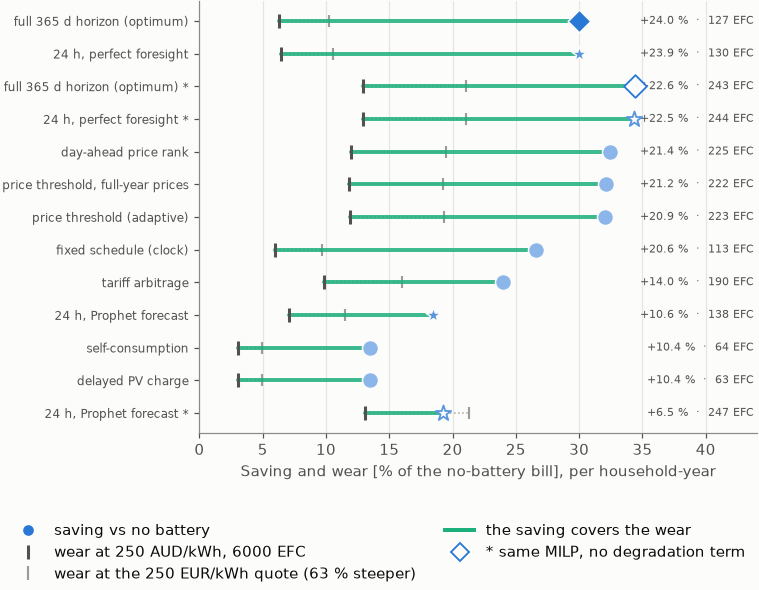

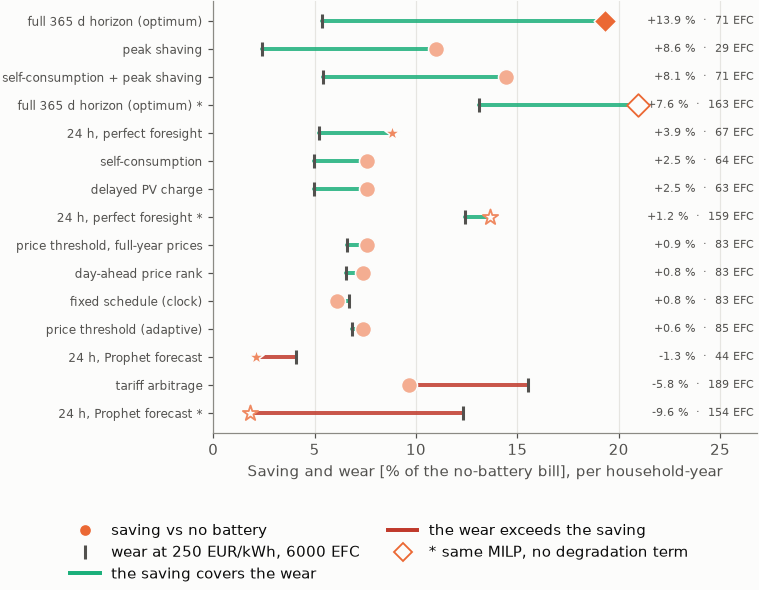

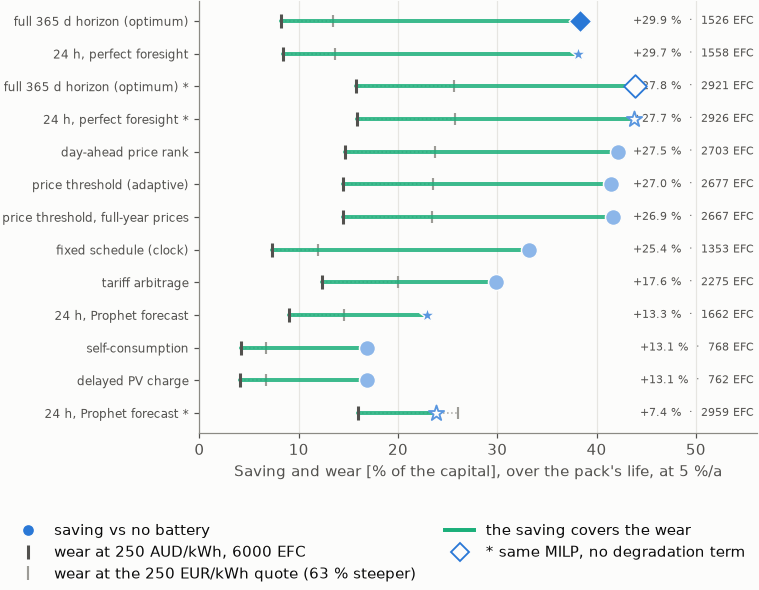

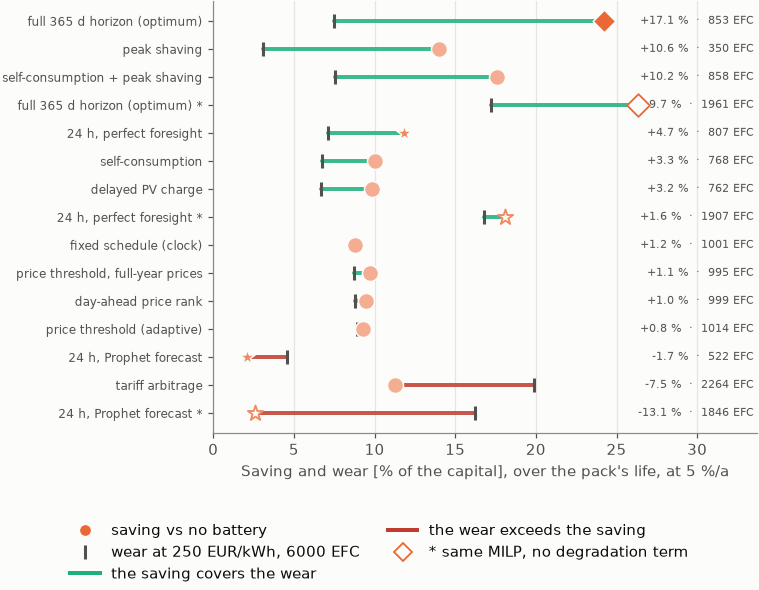

In [13]:
### What a saving costs in pack life: the year's saving against the year's wear
# One row per controller, name on the y axis where it always fits. The mark is
# the median household's OPERATING saving, the tick is that household's wear,
# and the bar between them is what is left over -- so "does this controller pay
# for the cycles it spends" is the direction of one bar, and the ranking is the
# order of the rows.
#
# THIS REPLACED A SCATTER of efc against saving, and not for taste. Ten to
# thirteen controllers land in a small region of that plane -- `delayed_pv_charge`
# and `self_consumption` are 0.5 cycles and 0.02 EUR apart -- and their names run
# to 54 characters. There is no legible layout: in the committed AU figure two
# markers coincided and one of their labels floated free with no leader, and in
# the SI figure the leader lines crossed. `place_labels`, the ~150-line
# ring-search placer that fought it, has no callers left and is gone.
#
# BOTH AXES ARE SHARES, which is what lets AU and SI be read against each other
# at all. In money the two panels were 270 AUD and 45 EUR wide over different
# bills, so the only available reading was within a panel; as a share the
# sentence is one unit on both.
#
# TWO VIEWS, AND TWO DENOMINATORS. The annual view is the simulated year against
# the year's no-battery bill -- "this controller earns 21 % of the bill and
# spends 12 % of it on pack life". The lifetime view discounts both marks over
# each row's own service life and divides by the CAPITAL: "over its life it
# earns 61 % of what the pack cost and spends 28 % of it on wear".
#
# The denominator has to change with the view or there is no second figure. A
# discounted saving over a discounted bill cancels `pv_factor` out of numerator
# and denominator alike and returns the annual number under a lifetime axis
# label; the first draft of this cell shipped two identical panels that way.
#
# COLOUR. Sign is green/red, NOT green/orange: orange is the SI tariff on every
# other figure here, and in the committed SI panel the orange saving marker and
# an orange over-budget bar were the same hue in the same image.
import Battery_Economics as be
from matplotlib.lines import Line2D

CAP_KWH = float(df_all["battery_cap"].median())

for view in VIEWS:
    for tariff, arm in hs.REFERENCE_ARM.items():
        sub, stars = with_nowear(long, arm)
        sub = sub[sub["controller"] != "no_battery"]
        if sub.empty or sub["efc"].isna().all():
            continue
        # TWO DENOMINATORS, one per view, and the choice is not cosmetic. The
        # annual view divides by the year's no-battery bill. The lifetime view
        # divides by the CAPITAL, not by the lifetime bill -- because dividing a
        # discounted saving by a discounted bill cancels `pv_factor` out of both
        # and returns the annual number with a different axis label. The first
        # draft of this cell did exactly that and produced two identical panels.
        # Against the capital it is a new statement and the one the lifetime
        # view exists for: "over its life this controller earns 61 % of what the
        # pack cost and spends 28 % of it on wear".
        if view["key"] == "annual":
            _pvf, _denom = 1.0, sub["baseline_cost_total"]
            _of = PCT_OF_BILL
        else:
            _pvf, _denom = sub["pv_factor"], sub["capex"]
            _of = PCT_OF_CAPEX
        work = sub.assign(
            _save=100.0 * (sub["saving_operating"] * _pvf) / _denom,
            _wear=100.0 * (sub["wear_eur"] * _pvf) / _denom,
            _net=100.0 * (sub["saving_annual_net"] * _pvf) / _denom,
            # Cycles over the same horizon: the year's EFC in the annual view,
            # the whole pack life's in the lifetime one.
            _efc=sub["efc"] * (1.0 if view["key"] == "annual"
                               else sub["service_life_y"]))
        med = (work.groupby("controller")
               .agg(saving=("_save", "median"), wear=("_wear", "median"),
                    net=("_net", "median"), efc=("_efc", "median"),
                    binds=("life_binds_on_cycles", "mean"))
               .dropna().sort_values("net", ascending=False))
        ypos = np.arange(len(med))[::-1]          # best at the top

        # The rate the sweep ACCOUNTS wear at, read from the frame -- so a sweep
        # solved at another pack price moves this figure with it instead of
        # being drawn against a constant nobody re-ran. NOT the rate the MILP was
        # charged: the no-degradation arms were charged nothing and their packs
        # wear anyway, which is the entire point of having them.
        _slope = float(sub["wear_rate_accounted"].dropna().median())
        _slope_quote = (be.cycle_cost_eur_per_efc(CAP_KWH)
                        * hs.ARM_CURRENCY_PER_EUR[tariff])
        _ratio = _slope_quote / _slope
        _per_kwh = _slope * be.BATTERY_CYCLE_LIMIT_EFC / CAP_KWH
        # AU only: the sweep charged 0.4167 in the ARM'S money, i.e. 250 AUD/kWh,
        # while the honest quote is 250 EUR/kWh (0.678 AUD/EFC, 63 % steeper).
        # On SI the two coincide, because the arm bills in the currency the pack
        # is quoted in. Carried as a second, fainter tick rather than dropped:
        # it is the sensitivity check on a caption that used to be wrong.
        _quoted = abs(_ratio - 1.0) > 1e-9

        fig, ax = plt.subplots(figsize=pf.figsize(ratio=0.82))
        for y, (c, r) in zip(ypos, med.iterrows()):
            if _quoted:
                ax.plot([r["wear"], r["wear"] * _ratio], [y, y], ls=":", lw=1.0,
                        color=pf.mix(MUTED, SURFACE, 0.25), zorder=1)
                ax.scatter([r["wear"] * _ratio], [y], s=70, marker="|", lw=1.4,
                           color=pf.mix(MUTED, SURFACE, 0.15), zorder=2)
            # A MINIMUM-LENGTH BAR. Three SI controllers land within half a point
            # of break-even, where the bar is one pixel and its colour -- the
            # only thing that says which side of zero the row is on -- is
            # invisible. The bar is drawn from the wear tick to the saving mark,
            # or to a floor of 0.45 points in the right direction, whichever is
            # longer.
            _lo, _hi = r["wear"], r["saving"]
            if abs(_hi - _lo) < 0.45:
                _hi = _lo + 0.45 * (1.0 if r["net"] >= 0 else -1.0)
            ax.plot([_lo, _hi], [y, y], lw=2.6, solid_capstyle="round",
                    color=BEATS if r["net"] >= 0 else LOSES, alpha=0.85, zorder=3)
            ax.scatter([r["wear"]], [y], s=80, marker="|", color=INK_2, lw=2.0,
                       zorder=4)
            _star = is_nowear(c)
            ax.scatter([r["saving"]], [y], s=110, marker=ctrl_marker(c), zorder=5,
                       color=SURFACE if _star else ctrl_color(tariff, c),
                       edgecolor=ctrl_color(tariff, c) if _star else SURFACE,
                       lw=1.2 if _star else 1.0)
            # Right-aligned in one column at the axes edge, so thirteen of these
            # cannot collide with a mark or with each other however the data
            # moves. `net` is the study's own paired column: the per-household
            # difference, then the median, which differs from the gap between the
            # two marks by a few tenths because that is a difference of medians.
            _flag = " !" if r["binds"] > 0 else ""
            ax.annotate(f"{r['net']:+.1f} %  ·  {r['efc']:.0f} EFC{_flag}",
                        xy=(0.995, y), xycoords=("axes fraction", "data"),
                        ha="right", va="center", fontsize=7.5,
                        color=LOSES if r["binds"] > 0 else INK_2)

        _hi_x = max(med["saving"].max(),
                    med["wear"].max() * (_ratio if _quoted else 1.0))
        _lo_x = min(0.0, med["saving"].min(), med["wear"].min())
        # 1.28, not 1.45: the right-hand column needs a gutter, not a third of
        # the axis. Measured from the widest mark on the figure rather than from
        # the saving alone -- on AU the pale tick is the rightmost thing drawn.
        ax.set_xlim(_lo_x * 1.1 if _lo_x < 0 else 0, _hi_x * 1.28)
        if _lo_x < 0:
            ax.axvline(0, color=MUTED, lw=1.0, ls="--", zorder=1)
        ax.set_yticks(ypos, [tick_label(c) for c in med.index])
        ax.tick_params(axis="y", labelsize=8)
        ax.grid(axis="y", visible=False)
        finish(ax, xlabel=f"Saving and wear [{_of}], {view['per']}")

        # THE KEY IS BUILT FROM WHAT IS DRAWN. It carried "wear exceeds the
        # saving" on the AU panel, where no row is over budget and the entry
        # documents a colour the reader will never see.
        keys = [Line2D([], [], ls="", marker="o", ms=8,
                       color=ctrl_color(tariff, "milp_full"),
                       markeredgecolor=SURFACE, label="saving vs no battery"),
                Line2D([], [], ls="", marker="|", ms=9, markeredgewidth=2.0,
                       color=INK_2,
                       label=f"wear at {_per_kwh:,.0f} {hs.currency(arm)}/kWh, "
                             f"{be.BATTERY_CYCLE_LIMIT_EFC:.0f} EFC")]
        if _quoted:
            keys.append(Line2D([], [], ls="", marker="|", ms=9, markeredgewidth=1.4,
                               color=pf.mix(MUTED, SURFACE, 0.15),
                               label=f"wear at the {be.CAPEX_EUR_PER_KWH:.0f} "
                                     f"EUR/kWh quote (63 % steeper)"))
        if (med["net"] >= 0).any():
            keys.append(Line2D([], [], lw=2.6, color=BEATS,
                               label="the saving covers the wear"))
        if (med["net"] < 0).any():
            keys.append(Line2D([], [], lw=2.6, color=LOSES,
                               label="the wear exceeds the saving"))
        if stars:
            keys.append(Line2D([], [], ls="", marker="D", ms=8, color=SURFACE,
                               markeredgecolor=ctrl_color(tariff, "milp_full"),
                               markeredgewidth=1.2,
                               label="* same MILP, no degradation term"))
        _binding = med.index[med["binds"] > 0].tolist()
        pf.chart_frame(
            fig,
            f"What a saving costs in pack life, {tariff}, over {view['note']}. "
            f"Each row is one controller: the mark is the median household's "
            f"operating saving, the tick its wear at the rate the pack costs, "
            f"and the bar between them what is left, both as a share of that "
            f"household's {'no-battery bill' if view['key'] == 'annual' else 'installed capital'} "
            f"-- so the two tariffs read in one unit. "
            f"The printed figure is the paired median saving net of wear, taken "
            f"per household before the median, so it differs from the gap "
            f"between the marks by a few tenths of a point"
            + (f". Rows marked ! cycle the pack past its rated "
               f"{be.BATTERY_CYCLE_LIMIT_EFC:.0f} EFC inside the calendar band, "
               f"so their lifetime figures are an upper bound: "
               f"{', '.join(_binding)}" if _binding else ""),
            handles=keys, ncol=2)
        pf.show(fig, f"wear_vs_saving_{tariff.lower()}{view['suffix']}",
                layout="frame")

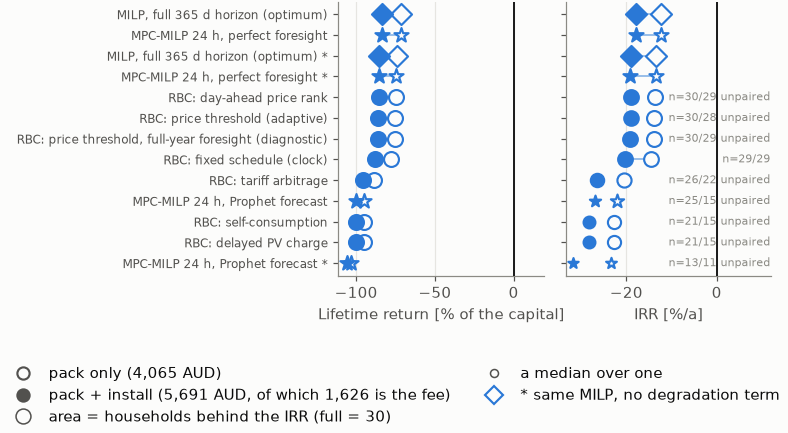

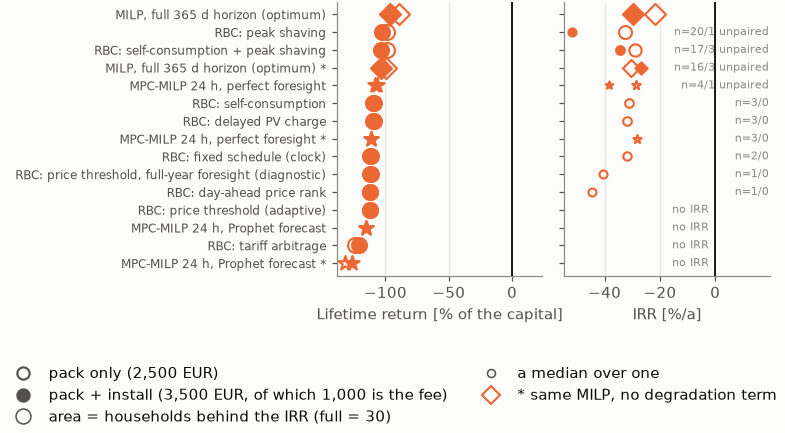

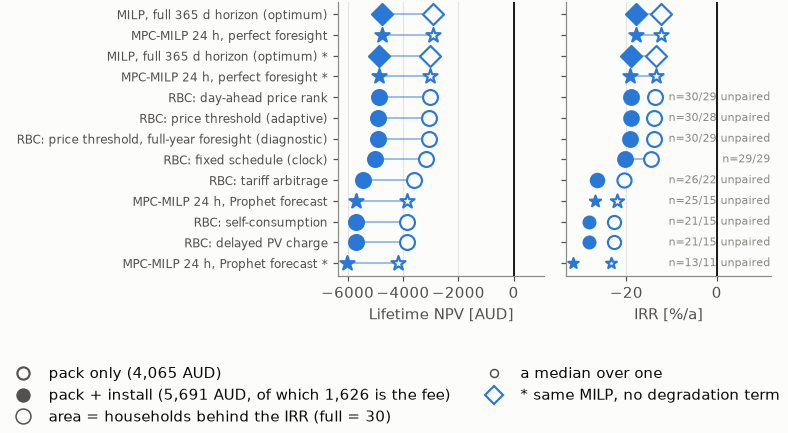

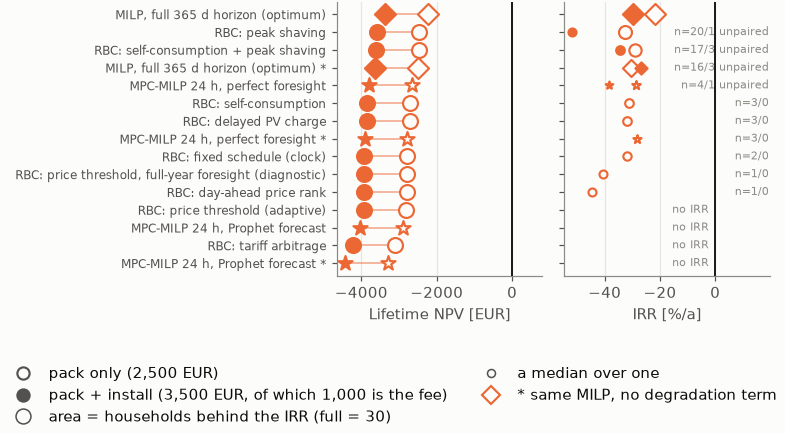

AU (AUD) -- median household, 12 y at 5% real, O&M 1.5%/a of installed capital
   controller                           net saving  NPV pack IRR pack   n  NPV +fee IRR +fee   n
   RBC: day-ahead price rank                 176.6     -3040    -13.6  30     -4882    -18.9  29
   MPC-MILP 24 h, Prophet forecast            85.2     -3850    -22.0  25     -5692    -26.8  15
   MILP, full 365 d horizon (optimum)        191.9     -2905    -12.3  30     -4747    -17.8  30
   n: households of 30 with a defined IRR. `n/a` is "no rate solves it", not a large negative one.
   the 1,626 AUD install alone costs 1,842 AUD of NPV and 5.5 points of IRR on MILP, full 365 d horizon (optimum).

SI (EUR) -- median household, 12 y at 5% real, O&M 1.5%/a of installed capital
   controller                             net saving  NPV pack IRR pack   n  NPV +fee IRR +fee   n
   RBC: self-consumption + peak shaving         40.1     -2477    -29.2  17     -3610    -34.6   3
   MPC-MILP 24 h, Prophet forecast       

In [14]:
### What the battery is actually worth: lifetime NPV and IRR, and what the install fee costs
# The question every figure above dodges. `saving` and `gain_share_pct` rank
# controllers against each other on one year; NOTHING there says whether the box
# is worth buying, and a ranking of positive-looking savings reads like a
# purchase recommendation. This is the same runs discounted over the pack's life
# against what the pack costs, and the answer is that every marker is to the
# LEFT of break-even on both tariffs.
#
# TWO VERSIONS, and the percentage one is the default:
#
#   ""        ROI -- the lifetime return as a share of the CAPITAL it is a
#             return on -- beside the IRR. Both are percentages, so AU and SI
#             are on one axis and "how far short does this fall" is a single
#             number on either tariff. `Battery_Economics` has returned
#             `ROI_pct` all along and `summarize` used to throw it away, which
#             is why this figure was drawn in money in the first place.
#   "_money"  the same thing in the arm's own currency, for the reader who wants
#             the cheque. Two axes, necessarily, because one of them is AUD.
#
# TWO MARKS PER ROW -- the "separate consideration" of the install fee:
#
#   hollow   pack only, 2500 EUR of cells (4065 AUD). "Is storage worth what
#            storage costs?"
#   solid    pack + 1000 EUR hybrid inverter and fitting. What a household pays.
#
# The gap is what the fee is worth over the life, and it is not a detail: on SI
# it is 29 % of the capital, it does not scale with pack size, and because O&M is
# charged as a share of installed capital it drags 15 EUR/a behind it.
#
# WHAT THE CONNECTING LINE MAY AND MAY NOT SAY. An IRR is NaN wherever the
# saving never covers the O&M charge, and `median()` drops NaN per column -- so
# the two ends of a row's IRR pair can be medians over different households. The
# committed figure drew the connector regardless, and on SI `peak_shaving` joined
# a median over twenty households to a median over ONE and asserted the fee
# costs 19.2 IRR points. It does not; that is one outlier against twenty. The
# line is now drawn only where both ends are over the SAME households, and the
# rows where it is missing are exactly the rows where no such comparison exists.
import Battery_Economics as be
from matplotlib.lines import Line2D

ECON = [("_pack_only", "pack only", False), ("", "pack + install", True)]

for money in (False, True):
    for tariff, arm in hs.REFERENCE_ARM.items():
        sub, stars = with_nowear(long, arm)
        sub = sub[sub["controller"] != "no_battery"]
        if sub.empty or sub["npv"].isna().all():
            continue
        cur = hs.currency(arm)
        cols = ["npv", "npv_pack_only", "roi_pct", "roi_pct_pack_only",
                "irr_pct", "irr_pct_pack_only", "capex", "capex_pack_only",
                "lifetime_saving", "lifetime_saving_pack_only"]
        med = sub.groupby("controller")[cols].median()
        med = med.sort_values("npv", ascending=False)   # best first, downward
        ypos = np.arange(len(med))[::-1]
        base = ctrl_color(tariff, "milp_full")

        # HOW MANY HOUSEHOLDS EACH IRR MARKER IS A MEDIAN OVER, and -- new --
        # how many are behind BOTH ends of a pair. The NPV and ROI panels are
        # always over every household, so only the IRR panel carries counts.
        nrs = sub.groupby("controller")[["irr_defined_pack_only",
                                         "irr_defined"]].sum().astype(int)
        # The households that have an IRR under BOTH scenarios. Only on these is
        # the fee's cost in IRR points a statement about the same people.
        paired = (sub.assign(_both=sub["irr_defined"]
                             & sub["irr_defined_pack_only"])
                  .groupby("controller")["_both"].sum().astype(int))
        n_hh = sub["dataset"].nunique()

        def _area(n):
            """Marker area for a median over `n` of `n_hh` households.

            Linear in n rather than sqrt(n): this is not a quantity anyone reads
            off a marker, it is a warning that the marker is thin, and the read
            that has to survive is "that one is smaller than the others".
            """
            return 25.0 + 70.0 * (n / max(n_hh, 1))

        _panels = ([("npv", f"Lifetime NPV [{cur}]"),
                    ("irr_pct", "IRR [%/a]")] if money else
                   [("roi_pct", f"Lifetime return [{PCT_OF_CAPEX}]"),
                    ("irr_pct", "IRR [%/a]")])
        fig, axes = plt.subplots(1, 2, figsize=pf.figsize(ratio=0.62), sharey=True)
        for ax, (col, unit) in zip(axes, _panels):
            for y, c in zip(ypos, med.index):
                xs = [med.loc[c, col + suf] for suf, _, _ in ECON]
                ns = [nrs.loc[c, "irr_defined" + suf] if col == "irr_pct" else n_hh
                      for suf, _, _ in ECON]
                # THE LINE ONLY WHERE IT IS A COMPARISON. On the NPV and ROI
                # panels both ends are over every household and it always is.
                _same = (col != "irr_pct") or (
                    paired.loc[c] == ns[0] == ns[1] and ns[0] > 0)
                if all(v == v for v in xs) and _same:
                    ax.plot(xs, [y, y], color=base, lw=1.1, zorder=2, alpha=0.55)
                for x, n, (suf, _, solid) in zip(xs, ns, ECON):
                    if x != x:
                        continue
                    ax.scatter([x], [y], s=_area(n), marker=ctrl_marker(c),
                               zorder=3, color=base if solid else SURFACE,
                               edgecolor=base, lw=1.4)
                if col == "irr_pct" and any(n < n_hh for n in ns):
                    _fin = [x for x in xs if x == x]
                    if _fin:
                        # BOTH NUMBERS, ALWAYS. This deduplicated, so a row over
                        # 29 households under both scenarios printed "n=29" and
                        # a row over 30 and 29 printed "n=30/29" -- two strings
                        # of different arity for the same kind of fact.
                        _txt = "n=" + "/".join(str(n) for n in ns)
                        if not _same and all(v == v for v in xs):
                            # Say why the line is missing, on the row it is
                            # missing from. Otherwise its absence reads as a
                            # rendering slip rather than as the point.
                            _txt += " unpaired"
                        # A RIGHT GUTTER, not a tag hung off the rightmost
                        # marker. At 6.5 pt and 7 pt of offset the count sat
                        # against the mark it qualified, and on the rows where
                        # the two marks are far apart it landed in the middle of
                        # the panel. Pinned to the axes edge it forms a column
                        # that reads down the figure, which is what cell 19 does
                        # with its break-even prices, and it is legible at 7.5.
                        ax.annotate(_txt, xy=(0.995, y),
                                    xycoords=("axes fraction", "data"),
                                    ha="right", va="center", color=MUTED,
                                    fontsize=7.5)
            # An IRR that does not EXIST is not a bad IRR, and a blank row would
            # read as a missing run. Said in words, on the row it belongs to,
            # and only where the row is empty -- a row with one mark left
            # carries its count beside that mark already.
            if col == "irr_pct":
                for y, c in zip(ypos, med.index):
                    if all(med.loc[c, "irr_pct" + suf] != med.loc[c, "irr_pct" + suf]
                           for suf, _, _ in ECON):
                        ax.annotate("no IRR", xy=(0, y), xytext=(-4, 0),
                                    textcoords="offset points", ha="right",
                                    va="center", color=MUTED, fontsize=7.5)
            # Break-even is the reading this whole figure exists for, so it is a
            # solid rule rather than a gridline, and it is named in the title,
            # which `titles=False` lifts into the caption.
            ax.axvline(0, color=INK, lw=1.2, zorder=4)
            ax.grid(axis="y", visible=False)
            _l, _r = ax.get_xlim()
            # Room for the gutter column on the IRR panel, which is the only one
            # that carries one; the ROI/NPV panel needs only label headroom.
            ax.set_xlim(_l, _r + (0.30 if col == "irr_pct" else 0.12)
                        * (_r - _l))
            finish(ax, xlabel=unit)

        axes[0].set_yticks(ypos, [LABEL.get(c, c) for c in med.index])
        axes[0].tick_params(axis="y", labelsize=8)
        _fee = med["capex"].iloc[0] - med["capex_pack_only"].iloc[0]
        keys = [
            Line2D([], [], marker="o", ls="", ms=8, color=SURFACE,
                   markeredgecolor=INK_2, markeredgewidth=1.4,
                   label=f"pack only ({med['capex_pack_only'].iloc[0]:,.0f} {cur})"),
            Line2D([], [], marker="o", ls="", ms=8, color=INK_2,
                   markeredgecolor=INK_2, markeredgewidth=1.4,
                   label=f"pack + install ({med['capex'].iloc[0]:,.0f} {cur}, "
                         f"of which {_fee:,.0f} is the fee)"),
            # THE SIZE ENCODING, DOCUMENTED. Marker area carries the sample
            # behind an IRR median and nothing in the image said so, which makes
            # it decoration rather than information.
            Line2D([], [], marker="o", ls="", color=SURFACE,
                   markeredgecolor=INK_2, markeredgewidth=1.0,
                   markersize=np.sqrt(_area(n_hh)),
                   label=f"area = households behind the IRR (full = {n_hh})"),
            Line2D([], [], marker="o", ls="", color=SURFACE,
                   markeredgecolor=INK_2, markeredgewidth=1.0,
                   markersize=np.sqrt(_area(1)), label="a median over one"),
        ]
        if stars:
            keys.append(Line2D([], [], marker="D", ls="", ms=8, color=SURFACE,
                               markeredgecolor=base, markeredgewidth=1.4,
                               label="* same MILP, no degradation term"))
        pf.chart_frame(
            fig,
            f"What the battery is worth over its life, {tariff}. The black rule "
            f"is break-even and every controller is to the left of it. The "
            f"{'NPV' if money else 'return'} panel is over all {n_hh} "
            f"households; an IRR exists only where the saving covers the O&M "
            f"charge, so the IRR panel's marker area and the n beside a row are "
            f"the households behind it (pack only / with the fee), and the two "
            f"marks are joined only where the same households are behind both "
            f"-- a row marked `unpaired` has no such comparison to draw",
            handles=keys, ncol=2)
        pf.show(fig, f"lifetime_economics_{tariff.lower()}"
                     f"{'_money' if money else ''}", layout="frame")

# The same thing in numbers, for the three controllers the text names.
for tariff, arm in hs.REFERENCE_ARM.items():
    if arm not in set(long["arm"]):
        continue
    cur = hs.currency(arm)
    _sub = long[long["arm"] == arm]
    tab = _sub.groupby("controller").median(numeric_only=True)
    # HOW MANY households each IRR median is over, exactly as `IRR_n` does in
    # the summary table. An IRR is NaN where the saving never covers the O&M
    # charge, and pandas drops those before taking a median -- so on SI
    # `peak_shaving` reports -52 %/a from ONE household while `milp_full`
    # reports -29.9 from thirty, and printed side by side with no n they read as
    # a ranking. The NPV beside them is always over all 30, which is the other
    # half of the trap: without these columns the two numbers on one row are
    # medians over different samples.
    nrs = _sub.groupby("controller")[["irr_defined", "irr_defined_pack_only"]].sum()
    _n_hh = _sub["dataset"].nunique()
    picks = [c for c in (hs.best_rule(long, arm), "prophet", "milp_full")
             if c in tab.index]
    # Wide enough for the three names PRINTED, not for every controller in the
    # frame. "RBC: self-consumption + peak shaving" is 36 characters and was
    # being truncated to "RBC: self-consumption + peak shavi" at 34.
    _w = max(len(LABEL.get(c, c)) for c in picks) + 2
    print(f"{tariff} ({cur}) -- median household, 12 y at "
          f"{be.DISCOUNT_RATE:.0%} real, O&M {be.OPEX_FRAC_OF_CAPEX_PER_YEAR:.1%}/a "
          f"of installed capital")
    print(f"   {'controller':<{_w}s}{'net saving':>11s}"
          f"{'NPV pack':>10s}{'IRR pack':>9s}{'n':>4s}"
          f"{'NPV +fee':>10s}{'IRR +fee':>9s}{'n':>4s}")
    for c in picks:
        def _r(v):
            return f"{v:9.1f}" if v == v else f"{'n/a':>9s}"
        print(f"   {LABEL.get(c, c):<{_w}s}{tab.loc[c, 'saving_annual_net']:11.1f}"
              f"{tab.loc[c, 'npv_pack_only']:10.0f}"
              f"{_r(tab.loc[c, 'irr_pct_pack_only'])}"
              f"{int(nrs.loc[c, 'irr_defined_pack_only']):>4d}"
              f"{tab.loc[c, 'npv']:10.0f}{_r(tab.loc[c, 'irr_pct'])}"
              f"{int(nrs.loc[c, 'irr_defined']):>4d}")
    print(f"   n: households of {_n_hh} with a defined IRR. `n/a` is "
          f"\"no rate solves it\", not a large negative one.")
    # The fee IN THIS ARM'S CURRENCY, and named by the controller it is measured
    # on rather than by position. `picks[-1]` is `milp_full` only while
    # `milp_full` is in the frame; when it is not, this sentence used to go on
    # calling whatever ended up last "the optimum".
    _on = picks[-1]
    _fee = tab.loc[_on, "capex"] - tab.loc[_on, "capex_pack_only"]
    print(f"   the {_fee:,.0f} {cur} install alone costs "
          f"{tab.loc[_on, 'npv_pack_only'] - tab.loc[_on, 'npv']:,.0f} "
          f"{cur} of NPV and "
          f"{tab.loc[_on, 'irr_pct_pack_only'] - tab.loc[_on, 'irr_pct']:.1f}"
          f" points of IRR on {LABEL.get(_on, _on)}.\n")

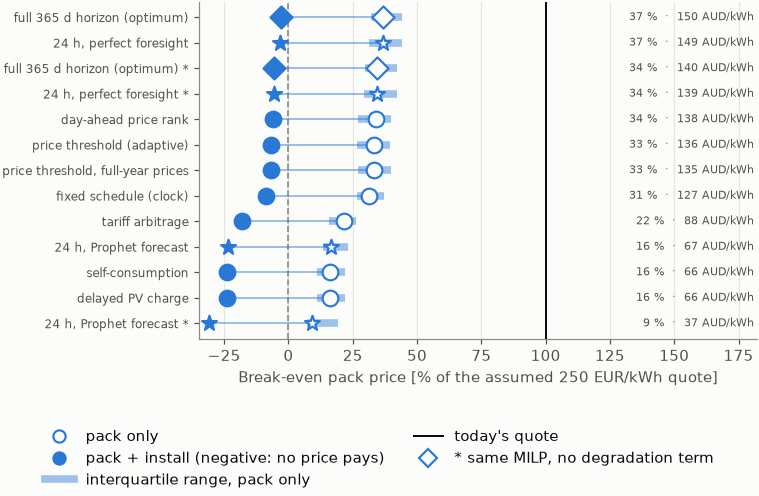

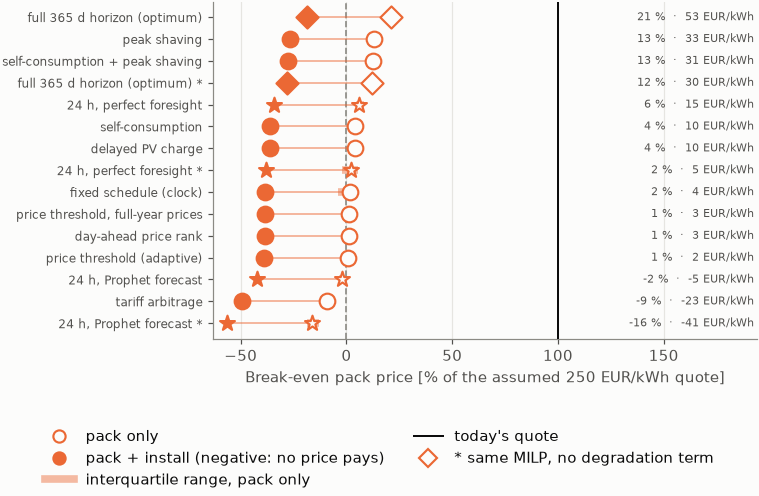

In [15]:
### How far the pack price has to fall: break-even capex
# THE FIGURE THE IRR PANEL WANTED TO BE. An IRR is NaN wherever the saving never
# covers the O&M charge, so the IRR panel above plots medians over one household
# beside medians over thirty, and has to spend a marker-area encoding, an `n`
# column and a suppressed connector on saying so. Break-even capex has none of
# that problem: it is defined for every household on every controller, because
# it is the price at which the annuity balances and that price always exists --
# it is simply negative where no positive price would do.
# `Battery_Economics` has returned `Break_Even_Capex_EUR_kWh` all along and
# nothing plotted it.
#
# AS A SHARE OF THE ASSUMED PRICE, not in currency per kWh: "the pack has to
# reach 37 % of what it costs today" is one sentence on both tariffs, where
# "150 AUD/kWh" and "53 EUR/kWh" are two numbers a reader converts before
# comparing. 100 % is today's quote.
#
# TWO MARKS PER ROW, the same hollow/solid convention as the lifetime figure,
# because the answer is completely different between them and that IS the result:
#
#   hollow  pack only. "Is storage worth what storage costs?" -- and it can be,
#           at 37 % of today's price on AU and 21 % on SI.
#   solid   pack + install. Every value is NEGATIVE: the fixed fee alone is more
#           than the saving can ever recover, so there is no cell price, free
#           included, at which the retrofit pays. A bar that crosses zero is a
#           controller for which the question stops being "how cheap" and starts
#           being "not at any price".
import Battery_Economics as be
from matplotlib.lines import Line2D

for tariff, arm in hs.REFERENCE_ARM.items():
    sub, stars = with_nowear(long, arm)
    sub = sub[sub["controller"] != "no_battery"]
    if sub.empty or sub["break_even_capex_pack_only"].isna().all():
        continue
    cur = hs.currency(arm)
    # The quote this arm was priced against, in the arm's own money -- the same
    # conversion `summarize` applies, read from the constants rather than typed.
    quote = be.CAPEX_EUR_PER_KWH * hs.ARM_CURRENCY_PER_EUR[tariff]
    work = sub.assign(
        _pack=100.0 * sub["break_even_capex_pack_only"] / quote,
        _full=100.0 * sub["break_even_capex"] / quote)
    med = (work.groupby("controller")
           .agg(pack=("_pack", "median"), full=("_full", "median"),
                q1=("_pack", lambda s: s.quantile(0.25)),
                q3=("_pack", lambda s: s.quantile(0.75)),
                n=("_pack", "count"))
           .sort_values("pack", ascending=False))
    ypos = np.arange(len(med))[::-1]
    base = ctrl_color(tariff, "milp_full")

    fig, ax = plt.subplots(figsize=pf.figsize(ratio=0.70))
    for y, (c, r) in zip(ypos, med.iterrows()):
        # The interquartile range on the pack-only reading, because the
        # households disagree by more than the controllers do -- which is itself
        # the result, and the one a purchase decision turns on.
        ax.plot([r["q1"], r["q3"]], [y, y], lw=5.0, solid_capstyle="butt",
                color=pf.mix(base, SURFACE, 0.55), zorder=2)
        # What the fee costs, as the distance between the two marks.
        ax.plot([r["full"], r["pack"]], [y, y], lw=1.1, color=base, alpha=0.55,
                zorder=3)
        _star = is_nowear(c)
        ax.scatter([r["pack"]], [y], s=105, marker=ctrl_marker(c), zorder=5,
                   color=SURFACE, edgecolor=base, lw=1.4)
        ax.scatter([r["full"]], [y], s=105, marker=ctrl_marker(c), zorder=5,
                   color=base, edgecolor=base, lw=1.4)
        ax.annotate(f"{r['pack']:.0f} %  ·  {r['pack'] * quote / 100:,.0f} "
                    f"{cur}/kWh",
                    xy=(0.995, y), xycoords=("axes fraction", "data"),
                    ha="right", va="center", fontsize=7.5, color=INK_2)
    # TODAY'S PRICE, and the point below which no price helps.
    ax.axvline(100.0, color=INK, lw=1.3, zorder=6)
    ax.axvline(0, color=MUTED, lw=1.1, ls="--", zorder=1)
    ax.set_yticks(ypos, [tick_label(c) for c in med.index])
    ax.tick_params(axis="y", labelsize=8)
    ax.grid(axis="y", visible=False)
    _lo = min(0.0, float(med["full"].min())) * 1.12
    ax.set_xlim(_lo, 118.0 + 0.42 * (118.0 - _lo))
    finish(ax, xlabel=f"Break-even pack price [% of the assumed "
                      f"{be.CAPEX_EUR_PER_KWH:.0f} EUR/kWh quote]")
    keys = [Line2D([], [], ls="", marker="o", ms=8, color=SURFACE,
                   markeredgecolor=base, markeredgewidth=1.4,
                   label="pack only"),
            Line2D([], [], ls="", marker="o", ms=8, color=base,
                   markeredgecolor=base, markeredgewidth=1.4,
                   label="pack + install (negative: no price pays)"),
            Line2D([], [], lw=5.0, color=pf.mix(base, SURFACE, 0.55),
                   label="interquartile range, pack only"),
            Line2D([], [], lw=1.3, color=INK, label="today's quote")]
    if stars:
        keys.append(Line2D([], [], ls="", marker="D", ms=8, color=SURFACE,
                           markeredgecolor=base, markeredgewidth=1.4,
                           label="* same MILP, no degradation term"))
    pf.chart_frame(
        fig,
        f"How far the pack price has to fall before the battery breaks even, "
        f"{tariff}, over {SAMPLE}. Each mark is the price at which that "
        f"controller's saving exactly covers capital recovery and O&M, as a "
        f"share of the {be.CAPEX_EUR_PER_KWH:.0f} EUR/kWh the study assumes. "
        f"The printed figure is the pack-only reading. Unlike an IRR this is "
        f"defined for every household, so every marker is a median over all "
        f"{int(med['n'].max())} of them. With the install fee in, every value "
        f"is negative -- the fixed cost alone exceeds what the saving can "
        f"recover, so no cell price pays, free included",
        handles=keys, ncol=2)
    pf.show(fig, f"break_even_capex_{tariff.lower()}", layout="frame")


findfont: Failed to find font weight semibold, now using 700.


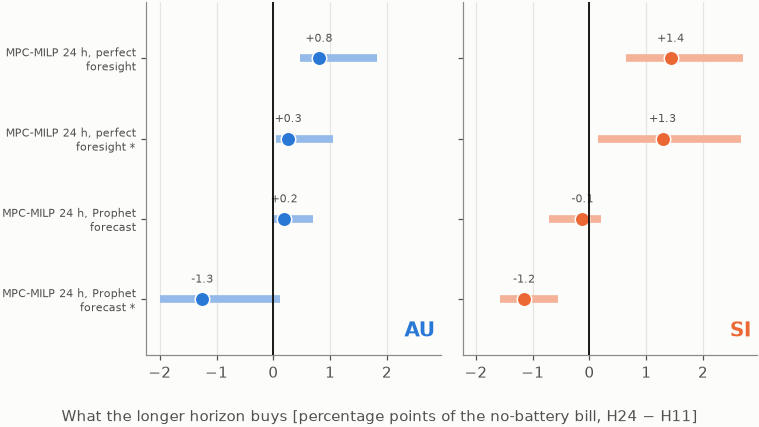

In [16]:
### The horizon axis: what 24 h of foresight buys over 11 h
# ONE OF THE STUDY'S THREE AXES AND IT HAD NO FIGURE. H24 against H11 appeared
# only as two rows in the arm table, where the comparison is a subtraction the
# reader does by eye across a page. The horizon is the gate-closure question --
# an 11 h horizon is what a household bidding into a day-ahead market actually
# has -- so it deserves to be read directly.
#
# PAIRED, like everything else here: the same household under both horizons,
# differenced per household and then median'd. A difference of two medians would
# throw away the pairing, and the two medians can come from different households.
#
# The no-degradation arms run at both horizons too, so the figure carries the
# interaction as well: whether a shorter horizon costs more or less when the
# controller is not paying for its cycles.
import textwrap

H_ARMS = {}
for _t in sorted(set(df_all["tariff"])):
    for _suffix, _lab in (("", ""), ("_nowear", " *")):
        _long_h, _short_h = f"{_t}_H24{_suffix}", f"{_t}_H11{_suffix}"
        if {_long_h, _short_h} <= set(df_all["arm"]):
            H_ARMS[(_t, _lab)] = (_long_h, _short_h)

if H_ARMS:
    _tariffs = sorted({t for t, _ in H_ARMS})
    fig, axes = plt.subplots(1, len(_tariffs), figsize=pf.figsize(ratio=0.60),
                             sharey=True, sharex=True)
    axes = np.atleast_1d(axes)
    for ax, tariff in zip(axes, _tariffs):
        rows = []
        for (t, lab), (a_long, a_short) in H_ARMS.items():
            if t != tariff:
                continue
            wide = (long[long["arm"].isin((a_long, a_short))]
                    .pivot_table(index=["dataset", "controller"], columns="arm",
                                 values="saving_total_pct", observed=True))
            if a_long not in wide or a_short not in wide:
                continue
            # Only the MPC controllers see the horizon at all. A rule has no
            # horizon, and `milp_full` solves the whole year under both arms --
            # their rows are the same numbers twice, and putting them on a chart
            # about horizons would say there is something to read.
            for c in ("prophet", "oracle"):
                d = (wide[a_long] - wide[a_short]).xs(c, level="controller",
                                                      drop_level=True).dropna()
                if len(d):
                    rows.append((LABEL.get(c, c) + lab, float(d.median()),
                                 float(d.quantile(0.25)), float(d.quantile(0.75)),
                                 len(d)))
        if not rows:
            continue
        rows.sort(key=lambda r: r[1])
        y = np.arange(len(rows))
        for yi, (_lab, m, q1, q3, n) in zip(y, rows):
            ax.plot([q1, q3], [yi, yi], lw=5.0, solid_capstyle="butt",
                    color=pf.mix(TARIFF_COLOR[tariff], SURFACE, 0.5), zorder=2)
            ax.scatter([m], [yi], s=90, zorder=4, color=TARIFF_COLOR[tariff],
                       edgecolor=SURFACE, lw=1.0)
            ax.annotate(f"{m:+.1f}", xy=(m, yi), xytext=(0, 9),
                        textcoords="offset points", ha="center", va="bottom",
                        fontsize=7.5, color=INK_2)
        ax.set_yticks(y, [textwrap.fill(r[0], 26) for r in rows])
        ax.tick_params(axis="y", labelsize=7.5)
        ax.axvline(0, color=INK, lw=1.2, zorder=5)
        ax.grid(axis="y", visible=False)
        ax.set_ylim(-0.7, len(rows) - 0.3)
        ax.annotate(tariff, xy=(0.98, 0.04), xycoords="axes fraction",
                    ha="right", va="bottom", color=TARIFF_COLOR[tariff],
                    fontsize=13, fontweight="semibold")
    fig.supxlabel("What the longer horizon buys "
                  "[percentage points of the no-battery bill, H24 − H11]",
                  color=INK_2, fontsize=10)
    pf.chart_frame(
        fig,
        f"What 24 h of foresight buys over 11 h, paired per household over "
        f"{SAMPLE}. Positive is the longer horizon winning. Only the "
        f"receding-horizon controllers appear: a rule has no horizon, and the "
        f"whole-period solve sees the same year under both arms",
        subtitle="Marker: the median household. Bar: the interquartile range "
                 "across households. * same MILP, no degradation term",
        handles=[])
    pf.show(fig, "horizon_effect", layout="frame")
else:
    print("The H11 arms have not run; the horizon figure needs both horizons.")


### 7.4 Household heterogeneity

Every figure above is a median over the roster. These two ask the question a median cannot: is the forecast's regret concentrated in a few households, and do those households have anything in common?


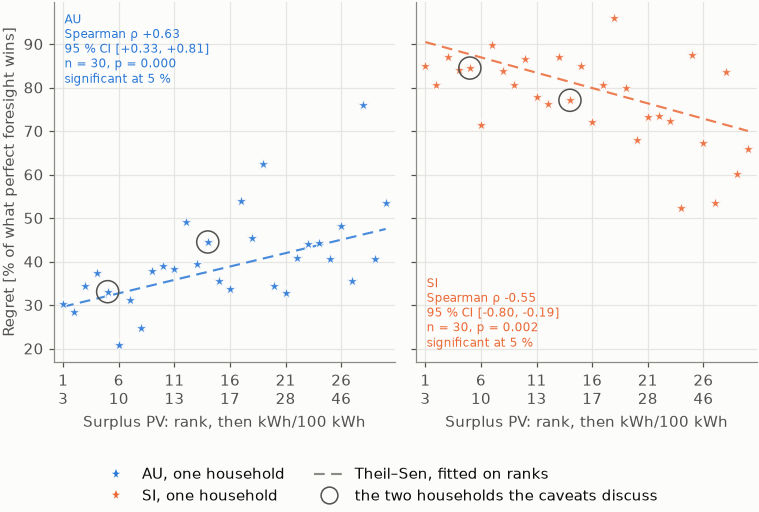

In [17]:
### 7.4 Which households is the forecast bad at?
from matplotlib.lines import Line2D
from scipy import stats as st

# The two households the caveats cell names, because they disagree about which
# channel Prophet is good at; marked here so that discussion has a picture.
# RINGED, NOT LABELLED. Both sit in the low-PV cluster where the points are
# densest, and a sweep of every sensible text offset put one label on another
# household's marker on at least one panel. The ring says "these two are the
# pair the caveats discuss"; the strip figure below, where every household has
# its own row and its own tick label, says which is which.
CAVEAT_HH = ["Ausgrid 127", "Ausgrid 148"]

# Which households is the forecast bad at, and is the answer a gradient?
#
# THE STATISTIC AND THE PICTURE DISAGREED. Spearman is a rank statistic -- it
# knows nothing about the spacing of the values -- and the old panels drew it
# on the RAW surplus-PV axis, which runs 4 to 96 with two thirds of the
# households under 30. So the eye reads a dense clump on the left and four
# stragglers on the right, a shape that has nothing to do with the +0.63 and
# -0.55 printed beside it, and the household at 96 looks like it is carrying
# the correlation when to Spearman it is worth exactly one rank more than the
# household at 66.
#
# The fix is to plot the space the test measures: x is the RANK of surplus PV,
# 1 to 30. Evenly spaced by construction, so every household has the same
# visual weight it has in the statistic, and the monotone trend the coefficient
# describes is the trend the eye sees. The raw values stay readable as a second
# tick row, because the axis still has to mean something physical.
#
# A FITTED LINE IS NOW ADMISSIBLE, where it was not before. The old cell
# refused one, correctly: an OLS line through raw values asserts a slope in
# units Spearman never looked at. In rank-rank space a Theil-Sen line IS the
# monotone trend -- it is a median of pairwise rank slopes, which is the same
# family of object as the coefficient -- so it adds the direction and the
# strength without claiming a functional form.
#
# And rho gains its interval. `rho +0.63, p = 0.0002` and `rho +0.63,
# 95 % CI [+0.36, +0.81]` are the same estimate; only the second says how
# firmly the study holds it.

_HET = ["con_skill_vs_naive", "gen_skill_vs_naive",
        "buy_no_battery", "sell_no_battery"]
het = (long[(long["controller"] == "prophet")
            & (long["arm"].isin(hs.REFERENCE_ARM.values()))]
       .join(df_all.set_index(["arm", "dataset"])[_HET], on=["arm", "dataset"])
       .assign(pv_ratio=lambda d: 100.0 * d["sell_no_battery"]
               / d["buy_no_battery"]))

# 0.72, not 0.64. Both axis labels are centred on a HALF-WIDTH axes and are
# longer than one: at 0.64 the two x labels met in the middle of the figure
# and ran off both ends, and the y label was taller than the axes it is
# centred on and ran off the top. Height is the knob -- the width is fixed at
# \textwidth -- and the labels below were cut to what a 3.1 in panel holds.
fig, axes = plt.subplots(1, len(hs.REFERENCE_ARM),
                         figsize=pf.figsize(ratio=0.72), sharey=True)
axes = np.atleast_1d(axes)
rhos = {}
for ax, tariff in zip(axes, sorted(hs.REFERENCE_ARM)):
    s = het[het["tariff"] == tariff].sort_values("pv_ratio")
    col = fs.TARIFF_COLOR[tariff]
    xr = st.rankdata(s["pv_ratio"].to_numpy())
    y = s["regret_pct_of_gain"].to_numpy()
    # The star is the MPC family marker: every point here is the same
    # controller, the arm's Prophet MPC, seen on thirty different households.
    ax.scatter(xr, y, s=62, marker=fs.FAMILY_MARKER["MPC"], color=col,
               edgecolor=SURFACE, lw=0.7, alpha=0.9, zorder=3)

    # THEIL-SEN IN RANK SPACE. The median of the pairwise slopes, which is
    # the rank-based line the rank-based coefficient describes -- not an OLS
    # fit, which would be a claim about magnitudes in a plane that has none.
    sl, ic, _, _ = st.theilslopes(y, xr)
    xx = np.array([xr.min(), xr.max()])
    ax.plot(xx, ic + sl * xx, color=col, lw=1.4, ls=(0, (5, 3)), zorder=2,
            alpha=0.85)

    rho, p, lo, hi, n = fs.spearman_ci(s["pv_ratio"], y)
    rhos[tariff] = (rho, p, lo, hi)
    fs.corner_block(ax, fs.rho_lines(tariff, rho, p, lo, hi, n), col, y)

    # RINGED, NOT LABELLED. Both households sit in the low-PV cluster where
    # the points are densest, and a sweep of every sensible text offset put
    # one label on another household's marker on at least one panel. The
    # ring says "these two are the pair the caveats discuss"; the strip
    # figure, where every household has its own row, says which is which.
    sel = s["dataset"].isin(CAVEAT_HH).to_numpy()
    ax.scatter(xr[sel], y[sel], s=210, marker="o", facecolor="none",
               edgecolor=INK_2, lw=1.0, zorder=4)

    # THE RAW VALUE, on a second tick row, so the rank axis still means
    # something physical. Every fifth rank, which is as many numbers as fit.
    ax.set_xlim(0.2, len(xr) + 0.8)
    ticks = np.arange(1, len(xr) + 1, 5)
    ax.set_xticks(ticks, [f"{int(t)}\n{s['pv_ratio'].to_numpy()[int(t)-1]:.0f}"
                          for t in ticks])
    finish(ax, xlabel="Surplus PV: rank, then kWh/100 kWh")
finish(axes[0], ylabel=f"Regret [{fs.PCT_OF_GAIN}]")

keys = [Line2D([], [], ls="", marker=fs.FAMILY_MARKER["MPC"], ms=9,
               color=fs.TARIFF_COLOR[t], markeredgecolor=SURFACE,
               label=f"{t}, one household") for t in sorted(hs.REFERENCE_ARM)]
keys += [Line2D([], [], color=MUTED, lw=1.4, ls=(0, (5, 3)),
                label="Theil–Sen, fitted on ranks"),
         Line2D([], [], ls="", marker="o", ms=11, markerfacecolor="none",
                color=INK_2, markeredgewidth=1.0,
                label="the two households the caveats discuss")]
pf.chart_frame(
    fig,
    f"Prophet's regret is not spread evenly, and what predicts it reverses "
    f"between the tariffs: the more surplus PV a household has, the WORSE "
    f"the forecast does on AU (ρ {rhos['AU'][0]:+.2f}, 95 % CI "
    f"[{rhos['AU'][2]:+.2f}, {rhos['AU'][3]:+.2f}]) and the BETTER on SI "
    f"(ρ {rhos['SI'][0]:+.2f}, [{rhos['SI'][2]:+.2f}, {rhos['SI'][3]:+.2f}])",
    subtitle=f"One point per household, {SAMPLE}, {hs.REFERENCE_ARM['AU']} "
             f"and {hs.REFERENCE_ARM['SI']}. x is the RANK of the "
             f"household's own export over its own import without a battery "
             f"-- a property of the house, not of a controller -- because "
             f"Spearman is a rank statistic and the raw axis, two thirds of "
             f"it under 30, draws a shape the coefficient does not describe. "
             f"The raw value is the second tick row. Cluster id and distance "
             f"to centroid were tested and explain nothing (|ρ| < 0.15, "
             f"p > 0.4): the households do not fall into kinds, they fall on "
             f"a gradient",
    handles=keys, ncol=2)
pf.show(fig, "household_heterogeneity", layout="frame")

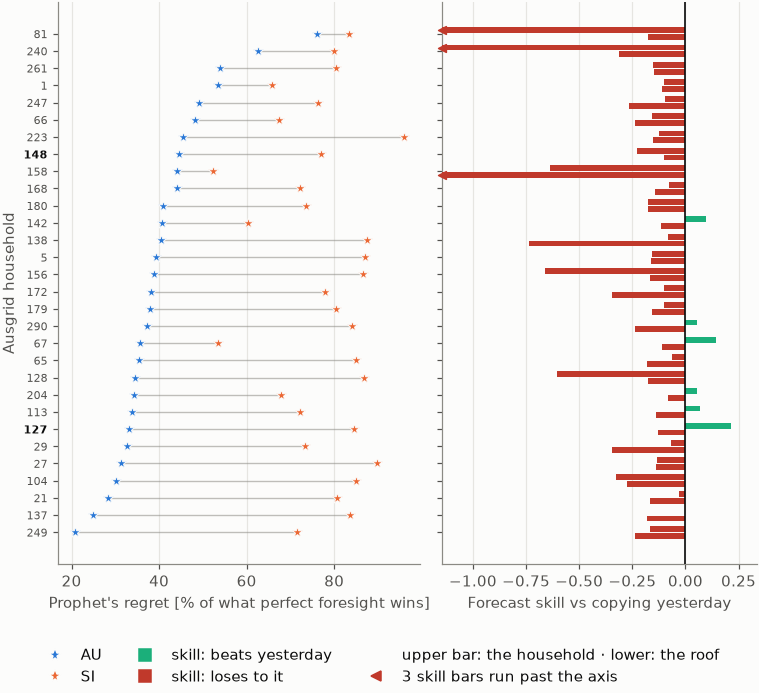

In [18]:
### 7.4b Every household, its regret and its forecast, side by side
# THE ROW ORDER IS THE REGRET, and everything else is read against it. Sorted by
# AU regret because some order has to be chosen and the cluster ids carry none;
# the SI mark on the same row then shows whether the two tariffs agree about
# which households are hard, and the skill panel whether the forecast's own
# error explains the ordering. Both answers are visible and both are negative,
# which is why this figure exists next to the scatter rather than instead of it.
#
# The regret panel puts AU and SI on ONE x axis. That is only legal because the
# measure is a share of what perfect foresight wins on that same household --
# the one form in which an AUD result and a EUR result are the same quantity.
from matplotlib.lines import Line2D
from scipy import stats as _st


_strip = (het.pivot_table(index="dataset", columns="tariff",
                          values="regret_pct_of_gain")
          .join(het[het["tariff"] == "AU"]
                .set_index("dataset")[["con_skill_vs_naive",
                                       "gen_skill_vs_naive"]]))
# The forecast is fitted per household and cached there, so the two skill
# columns are identical under every arm -- reading them off the AU rows is not
# a choice of tariff, it is the only value they have.
_strip = _strip.sort_values("AU", ascending=False)
ypos = np.arange(len(_strip))[::-1]
# ONE HOUSEHOLD SETS THE SKILL AXIS otherwise: Ausgrid 81's consumption model is
# 2.6x worse than copying yesterday (-1.57) and stretches the axis over a range
# the other twenty-nine never use, squeezing the mass of the panel -- which runs
# about -0.4 to +0.2 -- into a sixth of its width. `clip_window` from the ranking
# cell is the same fix for the same problem: the bar runs to the boundary and
# carries a caret there, and the count is named in the key.
_skv = pd.concat([_strip["con_skill_vs_naive"], _strip["gen_skill_vs_naive"]])
# Only the NEGATIVE tail is clipped. `clip_window`'s second argument is the
# list of values the window must keep, so passing the maximum forces the upper
# bound open: the positive side has no outlier to compress anything -- it tops
# out at +0.21 -- and that value is Ausgrid 127, the household this whole
# section is about. A first pass clipped it and drew the figure's most
# important bar running off the edge.
_swin = clip_window(_skv.to_numpy(), [_skv.max(), 0.0], q=0.04, pad=0.10)
_sout = 0

fig, axes = plt.subplots(1, 2, figsize=pf.figsize(ratio=0.95), sharey=True,
                         gridspec_kw={"width_ratios": [1.15, 1.0]})
ax_r, ax_s = axes

for y, (_hh, r) in zip(ypos, _strip.iterrows()):
    _v = [r[t] for t in sorted(hs.REFERENCE_ARM) if r[t] == r[t]]
    if len(_v) > 1:
        ax_r.plot([min(_v), max(_v)], [y, y], color=MUTED, lw=0.9, zorder=2,
                  alpha=0.55)
    for t in sorted(hs.REFERENCE_ARM):
        if r[t] == r[t]:
            ax_r.scatter([r[t]], [y], s=52, marker=FAMILY_MARKER["MPC"],
                         color=TARIFF_COLOR[t], edgecolor=SURFACE, lw=0.6,
                         zorder=3)
    # TWO THIN BARS FROM ZERO, upper = the household, lower = the roof, each
    # coloured by sign the way cell 14 colours the same quantity. Zero is
    # "copying yesterday", so a bar to the left is a forecast that lost to it.
    for _off, _col in ((0.20, "con_skill_vs_naive"), (-0.20, "gen_skill_vs_naive")):
        _s = r[_col]
        if _s != _s:
            continue
        _clip = min(max(_s, _swin[0]), _swin[1]) if _swin else _s
        ax_s.barh(y + _off, _clip, height=0.34, zorder=3,
                  color=BEATS if _s > 0 else LOSES)
        if _swin and _clip != _s:
            _sout += 1
            ax_s.scatter([_clip], [y + _off], s=26,
                         marker="<" if _s < _clip else ">",
                         color=BEATS if _s > 0 else LOSES, zorder=5,
                         clip_on=False)

if _swin:
    ax_s.set_xlim(*_swin)
ax_s.axvline(0, color=INK, lw=1.1, zorder=4)
for ax in axes:
    ax.grid(axis="y", visible=False)
ax_r.set_yticks(ypos, [d.split()[-1] for d in _strip.index])
ax_r.tick_params(axis="y", labelsize=7.5)
# The two the caveats name, findable without counting rows.
for _t, _d in zip(ax_r.get_yticklabels(), _strip.index):
    if _d in CAVEAT_HH:
        _t.set_color(INK)
        _t.set_fontweight("bold")
finish(ax_r, xlabel=f"Prophet's regret [{PCT_OF_GAIN}]")
finish(ax_s, xlabel="Forecast skill vs copying yesterday")
ax_r.set_ylabel("Ausgrid household", color=INK_2)

# The two readings this figure exists to make, computed rather than asserted.
_agree, _pa = _st.spearmanr(_strip["AU"], _strip["SI"])
_ord, _po = _st.spearmanr(_strip["AU"],
                          _strip[["con_skill_vs_naive",
                                  "gen_skill_vs_naive"]].mean(axis=1))
_nc = int((_strip["con_skill_vs_naive"] > 0).sum())
_ng = int((_strip["gen_skill_vs_naive"] > 0).sum())

_keys = [Line2D([], [], ls="", marker=FAMILY_MARKER["MPC"], ms=9,
                color=TARIFF_COLOR[t], markeredgecolor=SURFACE, label=t)
         for t in sorted(hs.REFERENCE_ARM)]
_keys += [Line2D([], [], marker="s", ls="", ms=8, color=BEATS,
                 label="skill: beats yesterday"),
          Line2D([], [], marker="s", ls="", ms=8, color=LOSES,
                 label="skill: loses to it"),
          Line2D([], [], ls="", marker=None,
                 label="upper bar: the household · lower: the roof")]
if _sout:
    _keys.append(Line2D([], [], ls="", marker="<", ms=7, color=LOSES,
                        label=f"{_sout} skill bars run past the axis"))

pf.chart_frame(
    fig,
    f"The two tariffs do not agree about which households are hard "
    f"(ρ {_agree:+.2f}, p = {_pa:.2f}, n = {len(_strip)}), and forecast skill "
    f"does not order the regret either (ρ {_ord:+.2f}, p = {_po:.2f})",
    subtitle=f"One row per household, {SAMPLE}, sorted by AU regret -- not by "
             f"cluster, whose ids are 1:1 with the households and carry no "
             f"order. Skill is a property of the household: the forecast is "
             f"fitted and cached per house, so both tariffs and both horizons "
             f"see the same number. {_nc} of {len(_strip)} households have a "
             f"consumption channel that beats copying yesterday and {_ng} has "
             f"a generation channel that does; Ausgrid 127 and 148, in bold, "
             f"are the pair that disagree about which channel is the better one",
    handles=_keys, ncol=3)
pf.show(fig, "household_regret_strip", layout="frame")

## 5. Read-out

The households are **paired** — every one is run under every arm — so the per-site
difference is the unit of analysis, and a box plot of two independent-looking
distributions understates the evidence. Wilcoxon signed-rank rather than a t-test: 30 sites
of cost differences are not plausibly normal and a few of them sit far out.

In [19]:
### Every controller against MILP+Prophet, household by household
for tariff, arm in hs.REFERENCE_ARM.items():
    if arm not in set(long["arm"]):
        continue
    rep = hs.paired_controllers(long, arm, reference="prophet")
    if rep.empty:
        continue
    # CANONICAL CONTROLLER ORDER, like every other table in this notebook.
    # `paired_controllers` pivots, so its rows came back sorted alphabetically
    # by the raw controller key -- which put `milp_full` between the two rules
    # and `no_battery` in the middle, and meant this table and the summary above
    # listed the same controllers in two different orders.
    _rank = {c: i for i, c in enumerate(hs.controller_columns(df_all))}
    rep = (rep.assign(_c=rep["comparison"].str.split(" - ").str[0].map(_rank))
              .sort_values("_c").drop(columns="_c"))
    # 56, not 38: "RBC: price threshold, full-year foresight (diagnostic)" is 54
    # characters and used to push every column after it out of line. The IQR
    # field is 20 rather than 18 because "[-116.96, -101.00]" is exactly 18, so
    # at 18 it butted straight against the median with no space between them
    # and the two numbers were read as one.
    _w = max(len(LABEL.get(c, c)) for c in _rank) + 2
    print(f"=== {tariff} ({arm}): controller - MILP+Prophet, per household ===")
    print(f"{'comparison':{_w}s}{'median':>9s}{'IQR':>20s}{'better':>8s}{'worse':>7s}{'p':>10s}")
    for _, r in rep.iterrows():
        name = r['comparison'].split(' - ')[0]
        p = "n/a" if r["p_value"] != r["p_value"] else f"{r['p_value']:.4f}"
        print(f"{LABEL.get(name, name):{_w}s}{r['median_diff']:9.2f}"
              f"{f'[{r.q1_diff:.2f}, {r.q3_diff:.2f}]':>20s}"
              f"{r['n_b_greater']:>8d}{r['n_a_greater']:>7d}{p:>10s}")
    print("  negative median = the controller is CHEAPER than MILP+Prophet")
    print()

### And every arm against its tariff's reference arm
for tariff in sorted(set(df_all["tariff"])):
    rep = hs.paired_arms(df_all, tariff, metric="cost_prophet")
    if rep.empty:
        continue
    print(f"=== {tariff}: arm - {hs.REFERENCE_ARM[tariff]}, per household ===")
    for _, r in rep.iterrows():
        p = "n/a" if r["p_value"] != r["p_value"] else f"{r['p_value']:.4f}"
        print(f"  {r['comparison']:44s}{r['median_diff']:9.2f}  p={p}")
    print()

=== AU (AU_H24): controller - MILP+Prophet, per household ===
comparison                                                 median                 IQR  better  worse         p
No battery                                                 147.04    [125.96, 187.40]       0     30    0.0000
RBC: self-consumption                                       34.27     [-16.96, 83.22]      11     19    0.0879
RBC: fixed schedule (clock)                                -57.64    [-67.94, -49.67]      30      0    0.0000
RBC: delayed PV charge                                      34.71     [-16.96, 83.23]      11     19    0.0767
RBC: price threshold (adaptive)                           -103.45   [-113.29, -97.94]      30      0    0.0000
RBC: day-ahead price rank                                 -106.17  [-116.96, -101.00]      30      0    0.0000
RBC: price threshold, full-year foresight (diagnostic)    -105.32   [-115.21, -99.55]      30      0    0.0000
RBC: tariff arbitrage                             

### Caveats

* **The optimum is now in the study.** `milp_full` is one MILP over the whole scored year,
  perfect foresight throughout, and it is what every `gain_share_pct` divides by. It is not
  a controller anyone could deploy; it is the denominator. `oracle` remains what it always
  was — a receding-horizon MPC on realised data, perfect foresight *within* 24 h or 11 h —
  and its name now says so.

  On AU the bound is over `Cost_EUR` directly. On SI it is over the **total**, because the
  dogovorjena moč is endogenous: the solve buys a cheaper contract, so its standing charge
  is part of the same decision and cannot be held fixed while the rest is optimised.
  `full_period_bound_check` asserts this per run and says so loudly if a controller ever
  gets underneath it. Below a horizon of two months it declines to claim a bound at all —
  no month then reads its contract from another month in the window.

* **Two clocks were nine hours apart, and are now one.** The Ausgrid files are stamped
  `Timestamp_UTC` with a `+00:00` suffix they never earned: they are local NSW wall-clock
  readings, daylight saving included — the PV centroid steps by an hour on the first Sunday
  in October and back on the first Sunday in April. `TariffCalculator` converted them to
  Australia/Sydney anyway and `si_cas` gave every rule a Europe/Ljubljana clock, so the
  EA025 peak window was charged against the household's early morning while the clock rules
  read a third time zone. Both now read the stamp. Every AU number in the previous run was
  produced under the old arrangement.
* **The ranking is read on `saving_total`, and on `saving_pct` it was wrong.** The
  whole-period optimum bounds bill + standing charge + wear, and nothing else. Read on the
  energy bill alone, three AU price rules score *above* the row labelled "optimum" — up to
  106.6 % of a gain that is supposed to be a ceiling. Nothing is wrong with those runs: the
  optimum pays a wear shadow price and a price rule does not, so the rule buys its saving out
  of pack life (225 EFC against 127) and a measure blind to wear books the proceeds. Every
  comparison figure is now drawn on `saving_total_pct`.

* **A percentage on AU is not a percentage on SI — unless it is a share of the same thing.**
  Money is not comparable across the two: different currencies over different bills, so
  `saving` in the arm's own units only settles comparisons *down* a tariff. Where the figures
  can, they divide by something each household has one of — its own no-battery bill, the gain
  perfect foresight wins on it, the capital invested in it — and those shares are comparable
  across tariffs because the denominator travels with the numerator. The remaining money
  figures carry both units on the label and are not meant to be read across.

* **A no-degradation MILP is the ablation, not a better controller.** The `*_nowear` arms
  remove the wear shadow price from the MILP objective and change nothing else. They cycle
  the pack roughly twice as hard, and once the cycles are billed at the price they actually
  cost they land *below* their wear-priced twins on every ranking — which is the term doing
  its job. Two things follow that the figures state and the reader should not have to infer:

  - The pack still wears. `cycle_cost_reporting_eur_per_efc` stays at the pack price on
    these arms, so `wear_eur` and every quantity built on it are billed identically across
    the pair. Reading the solved rate back as the accounting rate — which is what the code
    did before these arms existed — would have reported zero wear for the hardest-cycling
    controller in the study and put it at the top of a chart whose axis reads "net of wear".
  - The NPV discounts over the 12 y **calendar** band with the cycle limit deliberately off,
    because the cash cost of wear is already subtracted and charging it again as a shortened
    life would double-count. That was free while every controller stayed under ~272 EFC/a
    (6000/272 = 22 y, so the calendar always bound). It is no longer automatic: a controller
    that clears 500 EFC/a is cycle-limited inside the band, and `life_binds_on_cycles` marks
    those rows, whose lifetime figures are then an upper bound.
* **The saving is against the energy bill, not the invoice.** The standing charge is
  reported as `Fixed_EUR` and excluded from `Cost_EUR`. On AU no controller can move it —
  it is 705.30 AUD/a on every household — and it is not small beside the bill it sits next
  to: 705.30 AUD/a against a 791.67 AUD/a energy bill on Ausgrid 127, so a "40 % saving" on
  that bill is 21 % of what the household actually writes a cheque for. On SI it is *not*
  fixed — it moves with the dogovorjena moč the controller's own peaks agree to, 75.58 to
  251.94 EUR/a across these households — which is why every SI comparison in this notebook
  is made on the total rather than on `Cost_EUR`.
* **The MPC arms still optimise energy only.** On SI they are then billed an excess-power
  charge they never saw in their objective, which is why a peak-shaving rule can beat them
  there — and over the full scored year it does, on every one of the 30 households:
  `self_consumption_peak_shaving` is 28.55 EUR/a cheaper than MPC+Prophet on the median
  household (section 5). That is a statement about those objectives, not
  about MILP: `milp_full` carries the excess-power charge and the contract, and is not
  beaten. Giving the receding-horizon arms the same terms is the obvious next step and is
  not done here.

* **Every rule is now tuned to the price it is billed under.** `rbc.build_signals` used to
  build `sig.import_rate` from the Slovenian rate model on *both* arms — it reads
  `env.pricing_scheme`, and the Ausgrid environment sets that too, for the battery and the
  calendar rather than for its prices. So on AU `price_threshold`, `price_rank_daily`,
  `tariff_arbitrage` and `price_oracle` ranked their intervals on a series correlated 0.66
  with the one they paid, blind to the 0.0270 / 0.0720 / 0.2360 network steps that are the
  whole of EA025's signal. It now takes the arm's own rate vectors.

  Every quantile, window and share in the roster had therefore been fitted against the wrong
  distribution, so all of them were re-searched per tariff (`tune_rules.py`,
  `tune_fixed_schedule.py`; the tables are `hs.RULE_PARAMS` and
  `hs.FIXED_SCHEDULE_WINDOWS`). It is not a small correction: on AU `price_threshold` goes
  from 70.96 to 184.31 EUR/a net of wear and wants to trade on 11 % of intervals rather
  than 2 %.

  The tuning is **in-sample** — four households on AU, two on SI, the same year the study
  scores — so the rules carry a small optimistic bias that the MILP arms do not. With one
  or two parameters each and grids this coarse it should be slight, and the per-household
  worst case is printed beside every winner, but it is a real asymmetry and belongs here.

* **On SI there is no arbitrage to tune for.** GEN-I Dinamični lands on these profiles at
  0.074–0.088 EUR/kWh — a 0.014 spread against a 0.417 EUR cycle. The best `price_threshold`
  on a 44-point grid earns 0.25 EUR/a, and `price_rank_daily`'s unconstrained optimum is to
  stop trading altogether. The two peak-shaving rules earn 33–36 EUR/a on the same
  households. SI's money is the capacity charge, and a price rule cannot reach it.
* **Every controller still has perfect foresight of the price** inside its horizon. On AU
  that is close to true (pre-dispatch is published); it is the load and the roof that are
  forecast.
* **Which channel Prophet is good at varies by household**, and the study should not claim
  otherwise until the full panel is in. On Ausgrid 127 the PV model scores −0.13 skill
  against seasonal-naive while consumption scores +0.21; on Ausgrid 148 the ordering is the
  other way round — the roof is the better of the two (−0.10) and the household the worse
  (−0.23) — though on that site neither channel beats seasonal-naive at all. Six of the 30
  households have a consumption channel that beats yesterday; not one has a generation
  channel that does. That variation is the reason the `*_pvnaive` and `*_pvtruth` arms
  exist — a single forecast arm averages the two channels into one number and hides which
  one is carrying the result. `household_regret_strip` now plots it: both households are
  in bold on that figure, and the panel beside them shows that the skill ordering does not
  reproduce the regret ordering: against the mean of the two channels it is ρ = −0.33 at
  p = 0.08, the right sign but short of a 5 % bar on 30 households.
* **Skill does buy value, and the figure that said otherwise was reading the wrong
  sample.** `skill_vs_regret` used to correlate seven method medians against seven,
  which throws away the pairing every other comparison in this notebook depends on:
  every household runs under every arm. On those seven points AU came out ρ = −0.64
  at **p = 0.119**, and the caption said AU did not carry the claim. It does. Taken
  the way the rest of section 5 is taken — inside each household, across the seven
  methods, then across households — the correlation is negative on **28 of 30**
  households on AU and **30 of 30** on SI, sign test p = 9e-7 and p = 2e-9. Both
  readings are now printed side by side on that figure, with the between-method ρ
  carrying the bootstrap interval that says how little seven points support. The
  between-method reading is not wrong, it is weak, and it was the only one shown.

* **A rank statistic is now drawn on the rank axis.** `household_heterogeneity`
  reports Spearman, which knows nothing about the spacing of its inputs, on an axis
  where two thirds of the households sit under 30 and one sits at 96. The numbers
  did not change — ρ = +0.63 on AU and −0.55 on SI, exactly as above — but the
  picture now has the geometry the test measured, and carries a Theil–Sen line
  fitted in rank space, which is the one kind of line a rank statistic licenses.

* **Every bar on `forecast_channel_regret` now carries an interval and a test.** It
  drew fourteen paired medians with nothing to say whether 35 and 36 differ. Each
  bar now has a percentile bootstrap CI, and every row was tested against its
  panel's best with a Wilcoxon on the per-household differences, Holm-adjusted over
  the thirteen comparisons. All thirteen separate on both tariffs, so the ordering
  is real — which the figure could not previously assert.

* **The best forecast is not the same one on both tariffs, and public holidays are
  not where forecasts break.** Both results are in `FIGURES_FORECAST.ipynb`, which
  runs off these same caches. `hbd_median14` wins AU by 0.64 pp of the achievable
  gain (p = 0.0006, better on 22 of 30 households) and *loses* SI to plain
  `median14` by 1.90 pp (p = 0.0003, 23 of 30) — and the swap survives handing both
  a perfect PV forecast, so it is a consumption-channel effect, not a roof one.
  Public holidays, meanwhile, do not lower these households' consumption at all
  (+0.017 against their own workdays, p = 0.18, and the same test finds the weekend
  at p = 1e-4). What does break the forecasts is household absence: 37 runs across
  22 of the 30 houses, on which Prophet's error rises to ×1.53 while copying
  yesterday's falls to ×0.22, and Prophet throws away 34 % of the day's achievable
  gain against 9 % on a normal day.

* **What does sort the households is how much surplus PV they have, and it sorts them in
  opposite directions on the two tariffs.** Prophet's regret rises with the household's
  export-to-import ratio on AU (Spearman ρ = +0.63, p = 0.0002, n = 30) and falls with it
  on SI (ρ = −0.55, p = 0.0017) — see `household_heterogeneity`. The two tariffs therefore
  do not agree about which households are hard (ρ = −0.18, p = 0.35), which is worth
  stating because every other figure in the notebook is a roster median and cannot show
  it. Cluster id and `dist_to_centroid` were both tested and explain nothing (|ρ| < 0.15,
  p > 0.4); the 30 households are the centroid-nearest member of each of 30 clusters, so
  the cluster id is 1:1 with the household and carries no order to sort by.
* **Wear is now priced, not just reported.** Every MILP objective carries the pack price
  over its rated cycle life — 0.417 EUR per equivalent full cycle for the 10 kWh pack —
  through `wear_objective_terms`. It was previously a setting that recorded itself in the
  run config and reached no objective at all, so a battery that wore for nothing was asked
  to arbitrage cents against a marginal cost of zero. The rules have no objective, so for
  them wear is still an observation; that is why the comparison is on `saving_net_of_wear`
  and not on `saving`. With wear in the objective, the objective is deliberately no longer
  the reported bill.

* **The clock rule's windows are searched, not assumed.** `fixed_schedule` used one pair of
  windows for both tariffs, never tuned, and `discharge_hours` could not move a single kWh
  of discharge into the window it named. Both are fixed; the windows are now per tariff and
  come from a re-runnable (start × length) sweep scored net of wear.
* **`price_oracle` is a diagnostic.** It reads the whole year and is never a
  recommendation; it exists to split the gap to the MILP into "the rule is too simple" and
  "the rule cannot see the future".
* **One battery size.** 10 kWh nameplate at 1.5 kW throughout. The capacity sweep
  (2.5–30 kWh) is not in this notebook yet.

* **The competing method is a port, and it departs from its source on purpose in two
  places.** `hbd` is the forecaster of Perez-Pineiro, Skogestad & Boyd, *Home battery
  dispatch under a tiered peak power tariff* (Optimization and Engineering, 2026;
  [cvxgrp/home-battery-dispatch](https://github.com/cvxgrp/home-battery-dispatch)),
  transcribed in `Yoann/hbd_forecast.py` with every departure marked `DEPARTURE` at the line
  it happens. Two of them change what the numbers mean and belong here:

  1. **The quantile.** The paper fits its load baseline at `eta = 0.2` — in that module's
     sign convention the 80th percentile, i.e. a baseline deliberately biased *high*,
     because its tiered peak-power tariff punishes walking into a higher tier. This study
     fits **both channels at the median** (`eta = 0.5`). Every other method in the roster is
     a median-ish estimator, so importing that bias would confound "this method is better"
     with "this forecast is biased" and the roster would stop being like-for-like. Neither
     tariff modelled here has the tiered structure that bias is *for*. It is a considered
     choice rather than a simplification, and it is the reason a bare "we implemented their
     forecaster" would be the wrong claim to make. The quantile is a knob on the adapter
     (`eta_con`, `eta_gen`), and pricing it is a separate experiment.
  2. **`hbd_median14` is not their method.** It is their stage 2 — the residual AR — on this
     study's own stage 1, a 14-day median at the same clock position. It is reported as a
     variant, not as the reference implementation, and it is the one that wins: on the
     screening table it is the best forecaster on both channels (skill +0.23 / +0.13), while
     the faithful port scores +0.13 / +0.06 and its baseline-only ablation +0.01 / −0.12. The
     transferable idea is the DECOMPOSITION, not the Fourier basis.

  The horizon differs too, and is not a departure so much as a different problem: the
  reference dispatches against a monthly peak tier, this study against a time-of-use rate
  and an agreed-power charge, so the AR is fit for one day of horizon on one day of lookback
  rather than for theirs.

* **The pack is quoted in EUR and the AU arm bills in AUD, and the sweep did not convert
  it.** `wear_objective_terms` puts `cycle_cost_eur_per_efc(10 kWh)` — 0.4167 — in every MILP
  objective on *both* arms, unconverted, so the AU solves were dispatching against a pack they
  valued at 250 **AUD**/kWh (154 EUR/kWh) rather than 250 EUR/kWh. `wear_eur`, `Saving_net`
  and `Cost_total` are all at that same rate, so the study is internally consistent; it is the
  *quote* that is 38 % light on AU. Converting it would change the dispatch and invalidate
  every checkpoint, so it is left as solved and the two figures that touch it now say which
  rate they are drawing: the cycles/saving chart draws the charged rate solid and the honest
  250 EUR/kWh converted (0.678 AUD/EFC) faint beside it — no AU controller is under either of
  them, so the AU reading survives the correction. The
  lifetime `NPV`/`IRR` columns, which are not part of any dispatch, use the converted quote.

* **The battery does not pay for itself on either tariff, under either capex.** Best NPV is
  −4747 AUD on AU and −3367 EUR on SI with the install fee, −2905 AUD and −2234 EUR without
  it — both from `milp_full`, i.e. from a controller nobody can deploy. The comparison in
  this notebook is therefore between *control strategies for a pack that has already been
  bought*, and none of its rankings should be read as an investment case.

  The 1000 EUR install is reported separately rather than folded in because it changes the
  KIND of answer, not only its size. It is 29 % of the SI capital, it does not scale with
  pack size, and because O&M is charged as a share of installed capital it drags 15 EUR/a
  behind it. With the fee in, the O&M charge alone (52.5 EUR/a) exceeds the median saving of
  most SI controllers, so their IRR does not exist rather than being merely bad; without it
  the charge is 37.5 EUR/a and `self_consumption`, `peak_shaving` and the price rules
  acquire one. Neither reading is the "right" one — one answers "does the retrofit pay",
  the other "is storage worth what storage costs" — so the figure plots both and the summary
  table quotes the one the household actually writes a cheque for.


## 6. What each arm cost to run

Every table above ranks the arms by what they **earn**. This one ranks them by what they
**cost to compute**, which is the other half of whether a method is deployable: a forecast
worth a couple of EUR a year that needs a nightly Prophet fit is a different proposition
from one that needs a rolling median.

Wall clock per household, as the sweep actually ran it — `N_JOBS` households at once, one
thread each — so the column ranks the arms against each other on this machine rather than
stating what an arm would take alone on an idle one.

**The cache is in these numbers, not averaged out of them.** One worker runs every arm of
one household in `ARM_ORDER`, so the first arm to need a forecaster or a forecast-blind
oracle pays for it and every later arm that reads the same cache does not. That, and not a
harder model, is why `SI_H24` sits above the 14 SI arms that follow it, and why one arm
of each `hbd` pair carries the 48-quantile-regression fit for both.

**Two sittings, and `ran_on` says which.** The eight `hbd` arms were added after the other
23 had already run, so their times were measured days later against caches the earlier arms
had already warmed. The reconstruction cannot see across that gap — `AU_H24_hbd`'s thirty
gaps are all ~2.7 days, which `cap_s` correctly rejects — so the table holds the cache payer
of *each* sitting (`SI_H24` for the first, `AU_H24_hbd_median14` for the second) and those
two are not each other's peers. Read the ranking **within** a `ran_on` date, not down the
whole column. The `sum min` total is over the household-arms that have a recoverable time
and says how many it leaves out.


In [20]:
### Execution time per arm: wall clock per household, most expensive on top
rt = hs.arm_runtimes(RESULTS_DIR)

def _t(v, w=9):
    """Seconds, or `n/a` -- an arm with no time on record did not take no time."""
    return f"{'n/a':>{w}}" if pd.isna(v) else f"{v:{w}.1f}"

_w = max(len(a) for a in rt["arm"]) + 2
hdr = (f"{'arm':{_w}s}{'tariff':>7s}{'n':>4s}{'median s':>10s}{'mean s':>9s}"
       f"{'min s':>9s}{'max s':>9s}{'sum min':>9s}  {'ran on':10s}  source")
print(hdr)
print("-" * len(hdr))
for _, r in rt.iterrows():
    print(f"{r['arm']:{_w}s}{r['tariff']:>7s}{int(r['households']):>4d}"
          f"{_t(r['median_s'], 10)}{_t(r['mean_s'])}{_t(r['min_s'])}{_t(r['max_s'])}"
          f"{_t(r['total_min'])}  {r['ran_on']:10s}  {r['source']}")

# WHICH SITTING each arm was measured in. The eight hbd arms were added after
# the other 23 had run, so they were timed days later against caches those had
# already warmed. Ranking down the whole column compares the cache payer of one
# sitting with the cache payer of another; ranking within a date does not.
for _d, _g in rt.groupby("ran_on"):
    print(f"\n  {_d}: {len(_g)} arm(s) -- most expensive "
          f"{_g.iloc[0]['arm']} at {_t(_g.iloc[0]['median_s']).strip()} s median")

# Household-arms summed, NOT wall clock for the sweep: they ran N_JOBS at a
# time. And summed over the household-arms that HAVE a time -- the two arms
# below contribute nothing, which is why the total is quoted with its n.
_have = rt.loc[rt["total_min"].notna(), "households"].sum()
_all = int(rt["households"].max() * len(rt)) if len(rt) else 0
print(f"\n{rt['total_min'].sum() / 60:.1f} h of household-arm time over "
      f"{int(rt['total_min'].notna().sum())} of {len(rt)} arms "
      f"({int(_have)} of {_all} household-arms have a recoverable time); "
      f"the sweep spent that on {N_JOBS} workers.")

missing = rt.loc[rt["source"] == "unrecoverable", "arm"].tolist()
if missing:
    print(f"\n  n/a ({', '.join(missing)}): nothing to subtract -- the FIRST arm "
          f"of every household\n  has no predecessor to measure the gap from. "
          f"Only `runtime_s` can recover these.")
crossed = rt.loc[rt["source"] == "cross-session", ["arm", "dropped"]]
if len(crossed):
    print("\n  n/a (" + ", ".join(crossed["arm"]) + "): every gap was REJECTED, not "
          "absent. These arms\n  have a predecessor, but it was written in an "
          "earlier sitting, so the gap measures\n  the time between sessions "
          "rather than the work -- "
          + ", ".join(f"{r.arm} {int(r.dropped)}/{int(rt['households'].max())}"
                      for r in crossed.itertuples()) + " dropped by cap_s.")
if (rt["source"] == "reconstructed").any():
    print("\n  `reconstructed`: read off the gaps between checkpoint timestamps, which "
          "is\n  what recovers a sweep that ran before the pipeline recorded its own "
          "time.\n  Runs from now on store `runtime_s` in the checkpoint and report as "
          "`measured`;\n  delete an arm's checkpoints and re-run it to replace an "
          "estimate with a measurement.")

arm                           tariff   n  median s   mean s    min s    max s  sum min  ran on      source
----------------------------------------------------------------------------------------------------------
AU_H24_hbd_median14               AU  30     323.3    277.3     80.1    363.3    138.6  2026-09-11  reconstructed
SI_H24                            SI  30     183.0    182.5    176.5    188.3     91.3  2026-09-08  reconstructed
SI_H24_nowear                     SI  30     177.2    177.1    171.5    182.0     88.5  2026-09-14  measured
AU_H24_nowear                     AU  30     149.6    125.5     74.6    153.3     62.7  2026-09-14  measured
SI_H11                            SI  30     104.5    104.8     98.3    112.1     52.4  2026-09-08  reconstructed
SI_H11_nowear                     SI  30     101.2    101.1     96.3    106.7     50.6  2026-09-14  measured
AU_H24_hbd_baseline               AU  30      88.1     90.1     83.9    103.2     45.0  2026-09-11  reconstructed
SI_

## 7. Putting the figures in the article

Every figure here is authored at `\textwidth` (7.16 in). If they read small in the paper they are being **scaled down** by a single-column float, not drawn too narrow — the cell below emits the `figure*` blocks that stop that, with each figure's recorded caption already filled in.


In [21]:
### The LaTeX blocks for every figure, and why they are `figure*`
# THE FIGURES ARE NOT TOO NARROW; THEY ARE BEING SCALED DOWN. Every export in
# this notebook is authored at `IEEE_PAGE_W` = 7.16 in, which is \textwidth --
# check any `Results/Figures/hems/<name>/SOURCE.md` and it says `7.16 x ... in`.
# There is nothing column-width here to widen.
#
# What makes them read small is the include on the article side. A 7.16 in
# figure placed in a single-column `\begin{figure}` and included at
# `width=\columnwidth` is scaled to 3.5/7.16 = 49 %, and scaling a figure is
# exactly what halves every font in it. The fix is the float, not the figure:
# `figure*` spans both columns in IEEEtran and takes the graphic at
# `width=\textwidth`, i.e. at 100 %.
#
# So the knobs, in the order to reach for them:
#   the float      `figure*` + `width=\textwidth`  -- what the blocks below emit
#   the height     `pf.figsize(ratio=...)` on the cell, if a figure wants to be
#                  TALLER at the same width. Width is not a knob; it is fixed at
#                  \textwidth and every figure already uses all of it.
#   the type size  only if the figures are ALREADY in `figure*` and still read
#                  small. Then they are the right width and the fonts are too
#                  small for it, and the base size in Plotting_Functions is what
#                  to raise -- not the width, which cannot go any higher.
import json
from pathlib import Path

FIG_DIR = Path("..") / "Results" / "Figures" / "hems"
_blocks = []
for _d in sorted(p for p in FIG_DIR.iterdir() if p.is_dir()):
    _src = _d / "source.json"
    if not _src.is_file():
        continue
    _rec = json.loads(_src.read_text())
    # `finish` and `chart_frame` record their titles here because
    # `pf.use(titles=False)` keeps them out of the image -- so the caption the
    # article should carry is already written, and retyping it is how the two
    # drift apart.
    _cap = " ".join(_rec.get("caption") or []) or _d.name.replace("_", " ")
    _w = _rec["export"]["figsize_in"][0]
    _blocks.append((_d.name, _w, pf.latex_figure(_d.name, _cap, subdir="hems",
                                                 span=True)))

print(f"{len(_blocks)} figures, all at \\textwidth "
      f"({min(w for _, w, _ in _blocks):.2f}-{max(w for _, w, _ in _blocks):.2f} in "
      f"against IEEE_PAGE_W = {pf.IEEE_PAGE_W} and IEEE_COLUMN_W = "
      f"{pf.IEEE_COLUMN_W}).\n"
      f"Paste these; `figure*` is the both-column float and is why they will "
      f"stop being scaled to 49 %.\n")
for _name, _w, _blk in _blocks:
    print(_blk, "\n")


26 figures, all at \textwidth (7.16-7.16 in against IEEE_PAGE_W = 7.16 and IEEE_COLUMN_W = 3.5).
Paste these; `figure*` is the both-column float and is why they will stop being scaled to 49 %.

\begin{figure*}[!t]
  \centering
  \includegraphics[width=\textwidth]{hems/absence_forecast_breakdown/absence_forecast_breakdown}
  \caption{The days that break a forecast are not on any calendar: they are the days the household is away. Copying yesterday gets BETTER (×0.22); Prophet, which reads no recent actual, gets ×1.53 worse, and throws away three and a half times as much of what the day had to win — 171 absence days in 37 runs across 22 of 30 households -- three or more consecutive days under 0.55 of the household's own centred 29-day rolling median. (a) the longest run. (b) one point per household, log axis, 1.0 is no change. (c) money on AU, where a day is settleable: the raw cash falls because an empty house has less to win, which is why the right panel divides by that day's own achiev